In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.options.display.float_format = "{:.2f}".format

In [3]:
DATA_PATH = "Coffee Shop Sales.xlsx"

df = pd.read_excel(DATA_PATH)

df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [4]:
EXPECTED_COLUMNS = {
    "transaction_id",
    "transaction_date",
    "transaction_time",
    "transaction_qty",
    "store_id",
    "store_location",
    "product_id",
    "unit_price",
    "product_category",
    "product_type",
    "product_detail",
}

actual_columns = set(df.columns)

missing_columns = EXPECTED_COLUMNS - actual_columns
unexpected_columns = actual_columns - EXPECTED_COLUMNS

if missing_columns:
    raise ValueError(
        f"Missing required columns: {sorted(missing_columns)}"
    )

print("=" * 70)
print("DATA CONTRACT CHECK")
print("=" * 70)

print("Missing required columns :", len(missing_columns))
print("Unexpected columns       :", len(unexpected_columns))

if unexpected_columns:
    print(
        "Unexpected columns:",
        sorted(unexpected_columns)
    )

DATA CONTRACT CHECK
Missing required columns : 0
Unexpected columns       : 0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 12.5+ MB


In [6]:
df.shape

(149116, 11)

In [7]:
df.describe()

,transaction_id,transaction_date,transaction_qty,store_id,product_id,unit_price
count,149116.00,149116,149116.00,149116.00,149116.00,149116.00
mean,74737.37,2023-04-15 11:50:32.173609984,1.44,5.34,47.92,3.38
min,1.00,2023-01-01 00:00:00,1.00,3.00,1.00,0.80
25%,37335.75,2023-03-06 00:00:00,1.00,3.00,33.00,2.50
50%,74727.50,2023-04-24 00:00:00,1.00,5.00,47.00,3.00
75%,112094.25,2023-05-30 00:00:00,2.00,8.00,60.00,3.75
max,149456.00,2023-06-30 00:00:00,8.00,8.00,87.00,45.00
std,43153.60,NaN,0.54,2.07,17.93,2.66


In [8]:
df.nunique().sort_values(ascending=True)

store_location           3
store_id                 3
transaction_qty          6
product_category         9
product_type            29
unit_price              41
product_id              80
product_detail          80
transaction_date       181
transaction_time     25762
transaction_id      149116
dtype: int64

In [9]:
print("=" * 60)
print("Missing Values Summary")
print("=" * 60)

def missing_values_report(df):
    report = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percentage": df.isna().mean() * 100
    })

    report = report.sort_values(
        "missing_percentage",
        ascending=False
    )

    return report


report = missing_values_report(df)

print(report)

Missing Values Summary
                  missing_count  missing_percentage
transaction_id                0                0.00
transaction_date              0                0.00
transaction_time              0                0.00
transaction_qty               0                0.00
store_id                      0                0.00
store_location                0                0.00
product_id                    0                0.00
unit_price                    0                0.00
product_category              0                0.00
product_type                  0                0.00
product_detail                0                0.00


In [10]:
duplicate_transaction_ids = df["transaction_id"].duplicated().sum()

print("Duplicate transaction IDs:", duplicate_transaction_ids)

Duplicate transaction IDs: 0


In [11]:
print("\n" + "=" * 60)
print("Duplicate Rows")
print("=" * 60)

dup = df.duplicated()

dup_count = dup.sum()

print(f"Number of duplicate rows: {dup_count}")

df[dup]


Duplicate Rows
Number of duplicate rows: 0


,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail


In [12]:
print("Shape before removing duplicates:", df.shape)

df= df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape before removing duplicates: (149116, 11)
Shape after removing duplicates: (149116, 11)


In [13]:
df["datetime"] = pd.to_datetime(
    df["transaction_date"].astype(str)
    + " "
    + df["transaction_time"].astype(str),
    errors="coerce"
)

print("\n" + "=" * 60)
print("Timestamp Validation")
print("=" * 60)

invalid_datetime_count = df["datetime"].isna().sum()

if invalid_datetime_count > 0:
    raise ValueError(
        f"Found {invalid_datetime_count} invalid datetime values."
    )

print("Start Date:", df["datetime"].min())

print("End Date:", df["datetime"].max())

print(
    "Number of unique days:",
    df["datetime"].dt.date.nunique()
)

df = df.drop(columns=["transaction_date", "transaction_time"])


Timestamp Validation
Start Date: 2023-01-01 07:06:11
End Date: 2023-06-30 20:57:19
Number of unique days: 181


In [14]:
df = df.sort_values(
    ['store_id',"datetime"]
).reset_index(drop=True)

In [15]:
df.head(20)

,transaction_id,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,datetime
0,106,1,3,Astoria,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2023-01-01 11:01:48
1,107,1,3,Astoria,38,3.75,Coffee,Barista Espresso,Latte,2023-01-01 11:01:58
2,108,1,3,Astoria,75,3.50,Bakery,Pastry,Croissant,2023-01-01 11:01:58
3,112,1,3,Astoria,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,2023-01-01 11:08:11
4,114,1,3,Astoria,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,2023-01-01 11:09:01
5,115,1,3,Astoria,47,3.00,Tea,Brewed Green tea,Serenity Green Tea Lg,2023-01-01 11:10:21
6,116,1,3,Astoria,79,3.75,Bakery,Scone,Jumbo Savory Scone,2023-01-01 11:10:21
7,117,1,3,Astoria,46,2.50,Tea,Brewed Green tea,Serenity Green Tea Rg,2023-01-01 11:10:58
8,118,1,3,Astoria,43,3.00,Tea,Brewed herbal tea,Lemon Grass Lg,2023-01-01 11:12:29
9,119,2,3,Astoria,45,3.00,Tea,Brewed herbal tea,Peppermint Lg,2023-01-01 11:16:02


In [16]:
time_diff = (
    df.groupby("store_id")["datetime"]
    .diff()
)

print("\n" + "=" * 60)
print("Time Frequency")
print("=" * 60)

print(time_diff.value_counts().head())


Time Frequency
datetime
0 days 00:00:00    32326
0 days 00:00:04      775
0 days 00:00:05      775
0 days 00:00:15      760
0 days 00:00:02      755
Name: count, dtype: int64


In [17]:
df.groupby(["store_id", "datetime"]).size().describe()

count   116790.00
mean         1.28
std          0.51
min          1.00
25%          1.00
50%          1.00
75%          2.00
max          7.00
dtype: float64

In [18]:
df.groupby(["store_id", "datetime"]).size().value_counts().head(10)

1    87530
2    26424
3     2644
4      163
5       22
6        5
7        2
Name: count, dtype: int64

In [19]:
print("Start:", df["datetime"].min())
print("End:", df["datetime"].max())
print("Duration:", df["datetime"].max() - df["datetime"].min())

Start: 2023-01-01 07:06:11
End: 2023-06-30 20:57:19
Duration: 180 days 13:51:08


In [20]:
print(df["store_id"].nunique())
print(df.groupby("store_id").size().describe())

3
count       3.00
mean    49705.33
std      1667.04
min     47782.00
25%     49190.50
50%     50599.00
75%     50667.00
max     50735.00
dtype: float64


In [21]:
print("\n" + "=" * 60)
print("Transaction Time Gaps")
print("=" * 60)

missing_timestamps = (
    time_diff > pd.Timedelta(hours=1)
).sum()

print(
    "Number of gaps greater than 1 hour:",
    missing_timestamps
)


Transaction Time Gaps
Number of gaps greater than 1 hour: 558


In [22]:
print("\n" + "=" * 60)
print("Invalid Values")
print("=" * 60)

print(
    "Invalid transaction quantity:",
    (df["transaction_qty"] <= 0).sum()
)

print(
    "Invalid unit price:",
    (df["unit_price"] <= 0).sum()
)


Invalid Values
Invalid transaction quantity: 0
Invalid unit price: 0


In [23]:
print("\n" + "=" * 60)
print("Outliers")
print("=" * 60)

Q1 = df["transaction_qty"].quantile(0.25)
Q3 = df["transaction_qty"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["transaction_qty"] < lower_bound) |
    (df["transaction_qty"] > upper_bound)
]

print(f'lower_bound is {lower_bound}')

print(f'upper_bound is {upper_bound}')

print("Number of transaction quantity outliers:", len(outliers))


Outliers
lower_bound is -0.5
upper_bound is 3.5
Number of transaction quantity outliers: 36


In [24]:
outliers

,transaction_id,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,datetime
51900,4193,4,5,Lower Manhattan,65,0.80,Flavours,Sugar free syrup,Sugar Free Vanilla syrup,2023-01-08 12:58:32
51952,4382,4,5,Lower Manhattan,64,0.80,Flavours,Regular syrup,Hazelnut syrup,2023-01-08 19:32:15
55896,16520,4,5,Lower Manhattan,83,14.00,Branded,Housewares,I Need My Bean! Latte cup,2023-01-30 08:49:26
57430,21473,4,5,Lower Manhattan,65,0.80,Flavours,Sugar free syrup,Sugar Free Vanilla syrup,2023-02-08 10:41:55
57466,21589,4,5,Lower Manhattan,65,0.80,Flavours,Sugar free syrup,Sugar Free Vanilla syrup,2023-02-08 12:58:32
62908,38601,4,5,Lower Manhattan,65,0.80,Flavours,Sugar free syrup,Sugar Free Vanilla syrup,2023-03-08 10:01:24
62936,38657,4,5,Lower Manhattan,65,0.80,Flavours,Sugar free syrup,Sugar Free Vanilla syrup,2023-03-08 10:41:55
62983,38814,4,5,Lower Manhattan,64,0.80,Flavours,Regular syrup,Hazelnut syrup,2023-03-08 13:38:14
63044,39060,4,5,Lower Manhattan,64,0.80,Flavours,Regular syrup,Hazelnut syrup,2023-03-08 19:32:15
63114,39283,6,5,Lower Manhattan,82,12.00,Branded,Housewares,I Need My Bean! Diner mug,2023-03-09 09:04:04


In [25]:
print("\n" + "=" * 60)
print("Data Quality Check Completed")
print("=" * 60)

print("Final Shape:", df.shape)

display(df.head())


Data Quality Check Completed
Final Shape: (149116, 10)


,transaction_id,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,datetime
0,106,1,3,Astoria,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2023-01-01 11:01:48
1,107,1,3,Astoria,38,3.75,Coffee,Barista Espresso,Latte,2023-01-01 11:01:58
2,108,1,3,Astoria,75,3.50,Bakery,Pastry,Croissant,2023-01-01 11:01:58
3,112,1,3,Astoria,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,2023-01-01 11:08:11
4,114,1,3,Astoria,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,2023-01-01 11:09:01


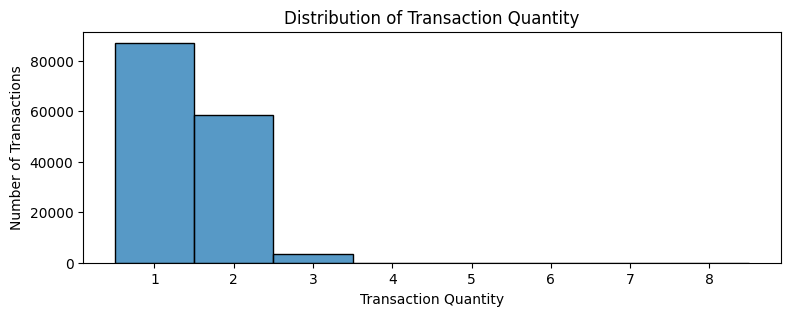

In [26]:
plt.figure(figsize=(9, 3))

sns.histplot(
    data=df,
    x="transaction_qty",
    discrete=True
)

plt.title("Distribution of Transaction Quantity")
plt.xlabel("Transaction Quantity")
plt.ylabel("Number of Transactions")

plt.show()

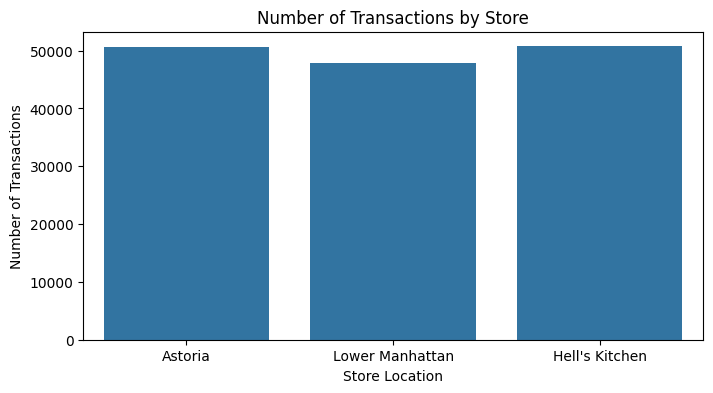

In [27]:
plt.figure(figsize=(8, 4))

sns.countplot(
    data=df,
    x="store_location"
)

plt.title("Number of Transactions by Store")
plt.xlabel("Store Location")
plt.ylabel("Number of Transactions")

plt.show()

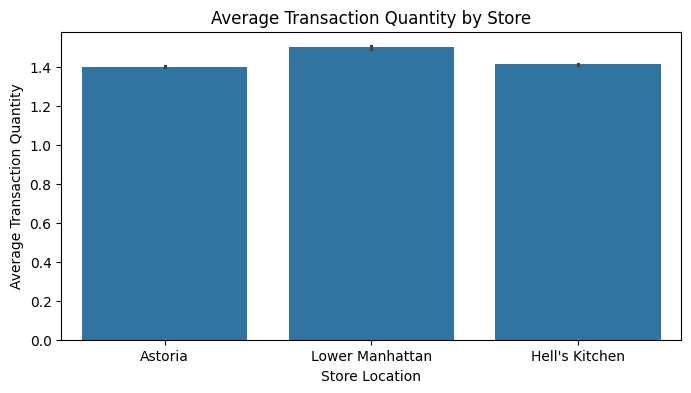

In [28]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=df,
    x="store_location",
    y="transaction_qty"
)

plt.title("Average Transaction Quantity by Store")
plt.xlabel("Store Location")
plt.ylabel("Average Transaction Quantity")

plt.show()

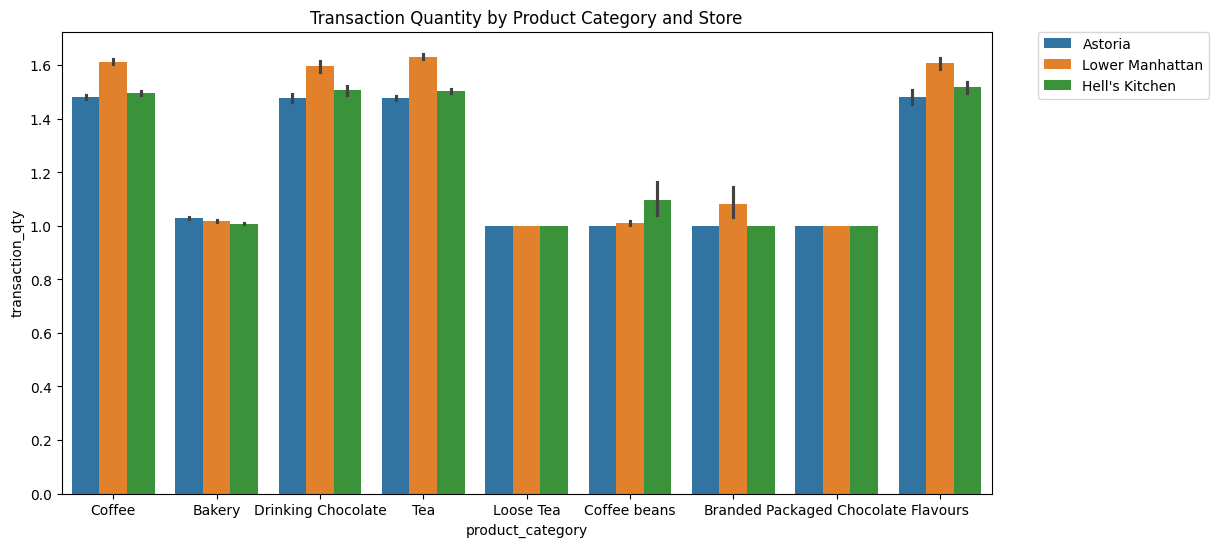

In [29]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df,
    x="product_category",
    y="transaction_qty",
    hue="store_location"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc=2,
    borderaxespad=0.
)

plt.title("Transaction Quantity by Product Category and Store")

plt.show()

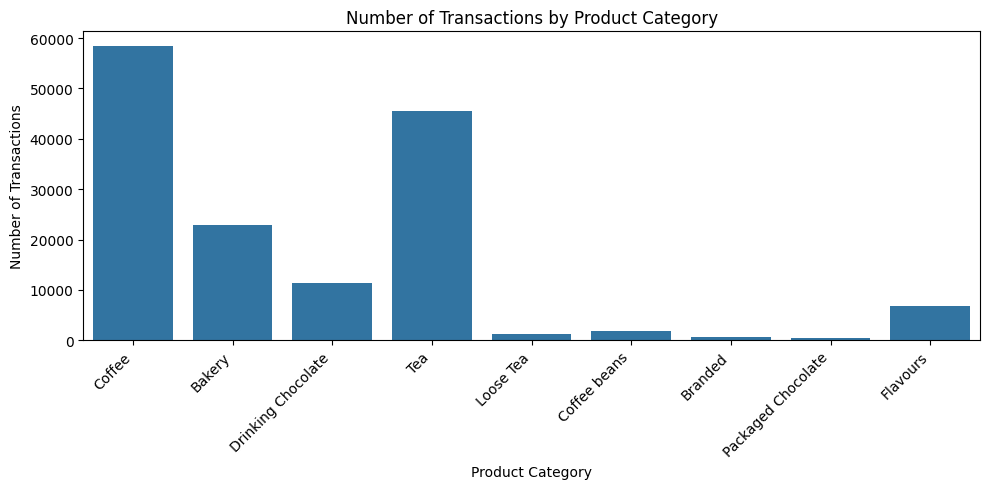

In [30]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="product_category"
)

plt.xticks(rotation=45, ha="right")

plt.title("Number of Transactions by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

In [31]:
df['revenue'] = df['transaction_qty'] * df['unit_price']

In [32]:
hourly_df = (
    df.set_index("datetime")
      .resample("1h")
      .agg({
          "revenue": "sum"})
      .reset_index()
)
print("=" * 60)
print("Hourly Data")
print("=" * 60)

print("Shape:", hourly_df.shape)

print("Start:", hourly_df["datetime"].min())

print("End:", hourly_df["datetime"].max())

Hourly Data
Shape: (4334, 2)
Start: 2023-01-01 07:00:00
End: 2023-06-30 20:00:00


In [33]:
hourly_df[hourly_df["revenue"] == 0]

,datetime,revenue
13,2023-01-01 20:00:00,0.00
14,2023-01-01 21:00:00,0.00
15,2023-01-01 22:00:00,0.00
16,2023-01-01 23:00:00,0.00
17,2023-01-02 00:00:00,0.00
...,...,...
4314,2023-06-30 01:00:00,0.00
4315,2023-06-30 02:00:00,0.00
4316,2023-06-30 03:00:00,0.00
4317,2023-06-30 04:00:00,0.00


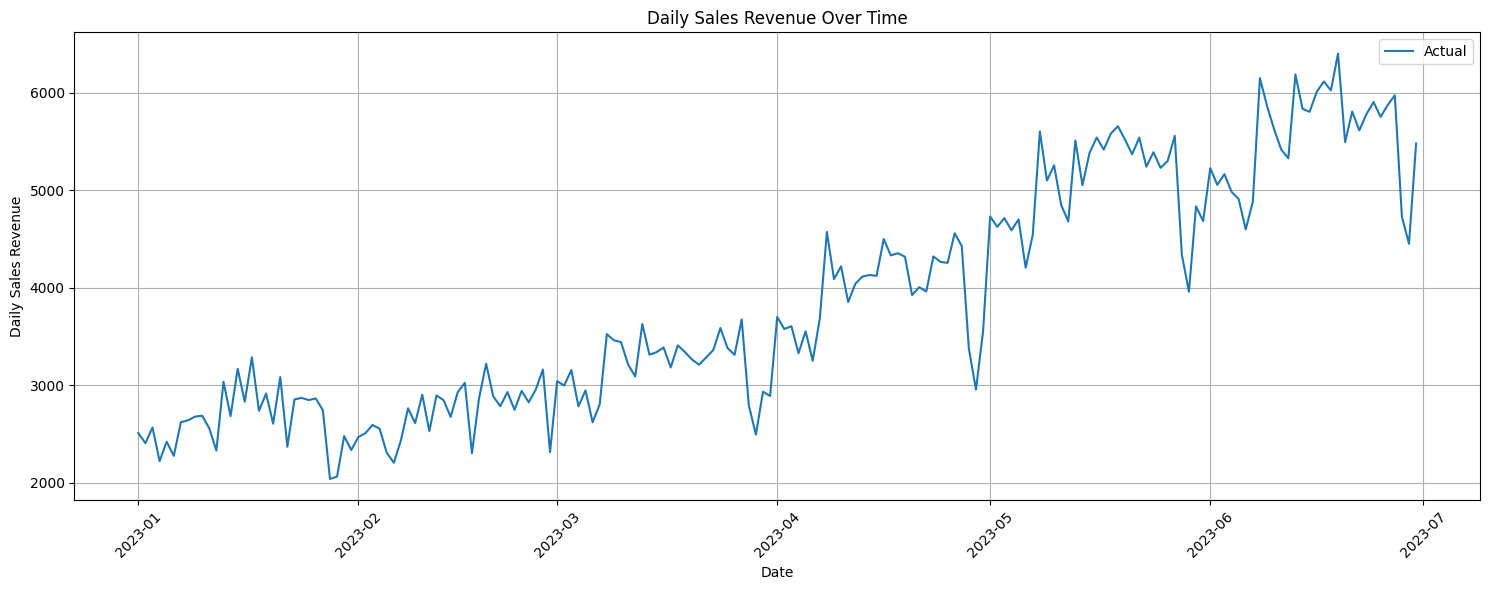

In [34]:
daily_df = (
    df.set_index("datetime")
      .resample("1D")["revenue"]
      .sum()
      .rename("revenue")
      .reset_index()
)

daily_sales = daily_df[["datetime", "revenue"]].copy()


daily_sales = daily_sales.rename(
    columns={
        "datetime": "ds",
        "revenue": "y"
    }
)

plt.figure(figsize=(15, 6))

plt.plot(
    daily_sales["ds"],
    daily_sales["y"],
    label="Actual"
)

plt.title("Daily Sales Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Daily Sales Revenue")

plt.legend()
plt.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
daily_sales.shape

(181, 2)

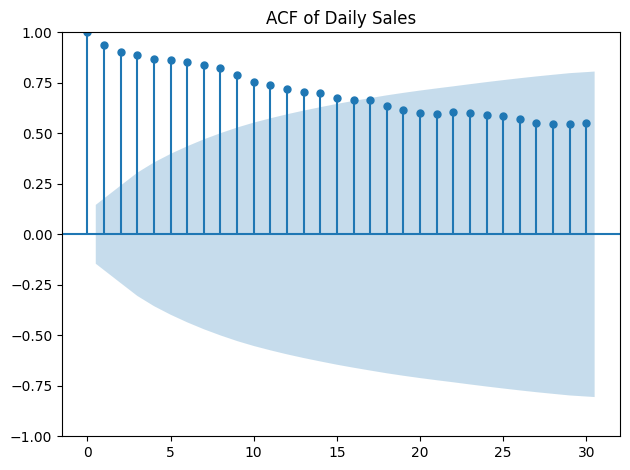

In [36]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sales = (
    daily_sales["y"]
    .astype(float)
    .dropna()
)

plot_acf(sales, lags=30)
plt.title("ACF of Daily Sales")
plt.tight_layout()
plt.show()


In [37]:
from statsmodels.tsa.stattools import acf

acf_values = acf(
    sales,
    nlags=28,
    fft=True
)

print("ACF at lag 1 day:", acf_values[1])
print("ACF at lag 7 days:", acf_values[7])
print("ACF at lag 14 days:", acf_values[14])
print("ACF at lag 21 days:", acf_values[21])
print("ACF at lag 28 days:", acf_values[28])

ACF at lag 1 day: 0.9349936741111171
ACF at lag 7 days: 0.8364655376987071
ACF at lag 14 days: 0.6982866282402953
ACF at lag 21 days: 0.5932444812889917
ACF at lag 28 days: 0.5464039071948598


In [38]:
from statsmodels.stats.diagnostic import acorr_ljungbox

result_daily = acorr_ljungbox(
    sales,
    lags=[1],
    return_df=True
)

result_weekly = acorr_ljungbox(
    sales,
    lags=[7, 14, 21, 28],
    return_df=True
)

print(result_daily)

print(result_weekly)

   lb_stat  lb_pvalue
1   160.87       0.00
    lb_stat  lb_pvalue
7   1010.84       0.00
14  1772.67       0.00
21  2346.73       0.00
28  2845.38       0.00


<Figure size 1200x500 with 0 Axes>

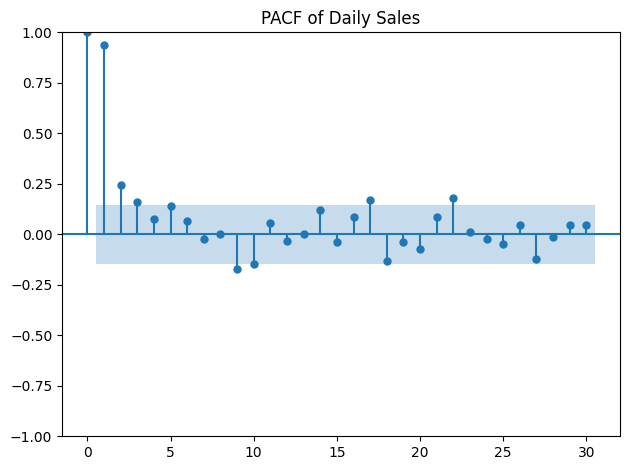

In [39]:
plt.figure(figsize=(12, 5))

plot_pacf(
    sales,
    lags=30
)

plt.title("PACF of Daily Sales")

plt.tight_layout()

plt.show()

In [40]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(
    sales.dropna()
)

print("=" * 60)
print("Stationarity Test - ADF")
print("=" * 60)

print("ADF Statistic:", adf_result[0])

print("p-value:", adf_result[1])

if adf_result[1] < 0.05:
    print("The series is stationary.")
else:
    print("The series is not stationary.")

Stationarity Test - ADF
ADF Statistic: -0.7085692033124137
p-value: 0.8445174174763055
The series is not stationary.


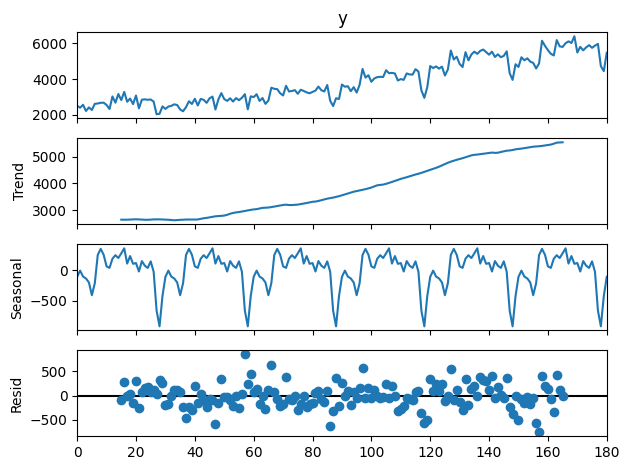

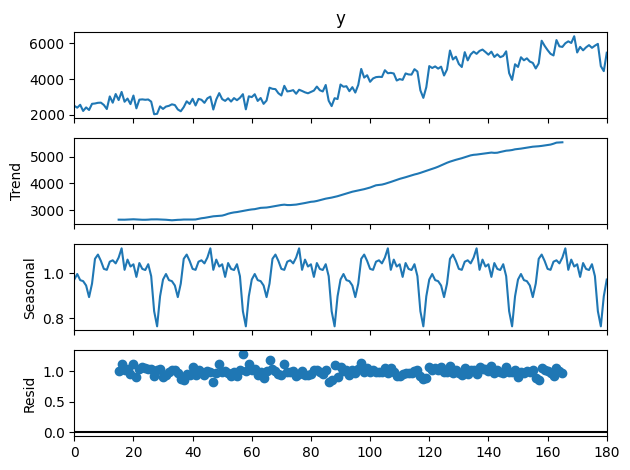

In [41]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp_daily_add = seasonal_decompose(
    sales.dropna(),
    model="additive",
    period=30
)

decomp_daily_add.plot()
plt.tight_layout()
plt.show()

decomp_daily_mult = seasonal_decompose(
    sales.dropna(),
    model="multiplicative",
    period=30
)

decomp_daily_mult.plot()
plt.tight_layout()
plt.show()


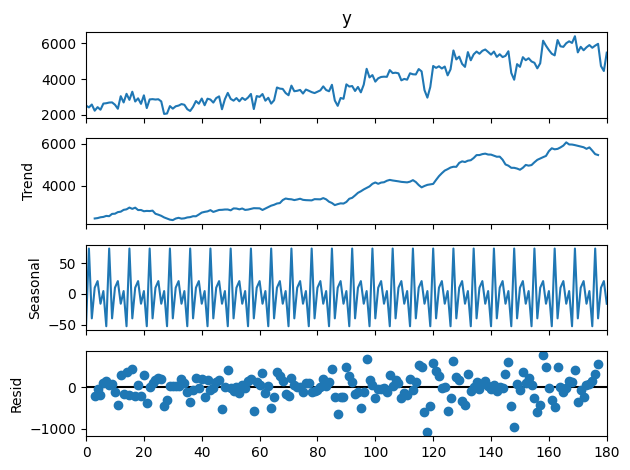

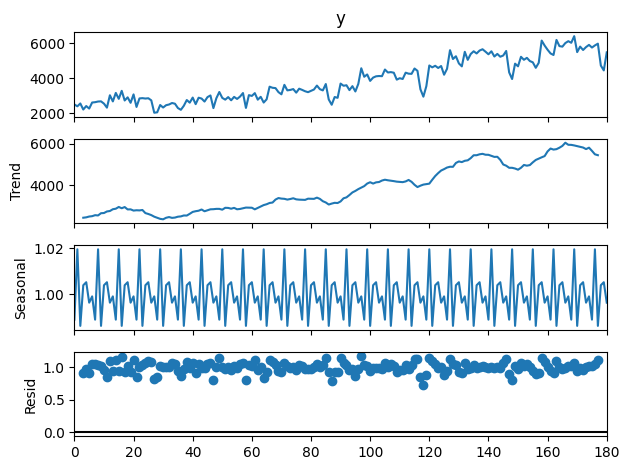

In [42]:
decomp_weekly_add = seasonal_decompose(
    sales.dropna(),
    model="additive",
    period=7
)

decomp_weekly_add.plot()
plt.tight_layout()
plt.show()

decomp_weekly_mult = seasonal_decompose(
    sales.dropna(),
    model="multiplicative",
    period=7
    )
decomp_weekly_mult.plot()
plt.tight_layout()
plt.show()

In [43]:
time_diff = daily_sales["ds"].diff()

print(time_diff.value_counts())

ds
1 days    180
Name: count, dtype: int64


In [44]:
expected_days = pd.date_range(
    daily_sales["ds"].min(),
    daily_sales["ds"].max(),
    freq="D"
)

missing_days = expected_days.difference(
    daily_sales["ds"].unique()
)

print("Missing days:", len(missing_days))
print(missing_days)

Missing days: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='D')


In [45]:
print("\n" + "=" * 60)
print("Events / Anomalies")
print("=" * 60)

print(
    "Transactions with zero price:",
    (daily_sales["y"] == 0).sum()
)


Events / Anomalies
Transactions with zero price: 0


BASELINE DATA
          ds       y
0 2023-01-01 2508.20
1 2023-01-02 2403.35
2 2023-01-03 2565.00
3 2023-01-04 2220.10
4 2023-01-05 2418.85

Shape: (181, 2)

Date Range: 2023-01-01 00:00:00 → 2023-06-30 00:00:00

Zero-sales days: 0

FOLD 1
Train: 2023-01-01 00:00:00 → 2023-01-31 00:00:00
Validation: 2023-02-01 00:00:00 → 2023-03-02 00:00:00
Naive                | MAE: 419.6910 | RMSE: 484.2605 | MASE: 1.5275 | MAPE: 14.5965%
Seasonal Naive       | MAE: 372.9050 | RMSE: 469.5128 | MASE: 1.3573 | MAPE: 13.4203%
Moving Average       | MAE: 388.3381 | RMSE: 452.3363 | MASE: 1.4134 | MAPE: 13.5035%
Seasonal Average     | MAE: 255.3298 | RMSE: 313.3427 | MASE: 0.9293 | MAPE: 9.2868%

FOLD 2
Train: 2023-01-01 00:00:00 → 2023-03-02 00:00:00
Validation: 2023-03-03 00:00:00 → 2023-04-01 00:00:00
Naive                | MAE: 334.8393 | RMSE: 377.9952 | MASE: 1.2654 | MAPE: 10.2149%
Seasonal Naive       | MAE: 411.2910 | RMSE: 479.4547 | MASE: 1.5543 | MAPE: 12.6748%
Moving Average       | MAE: 388

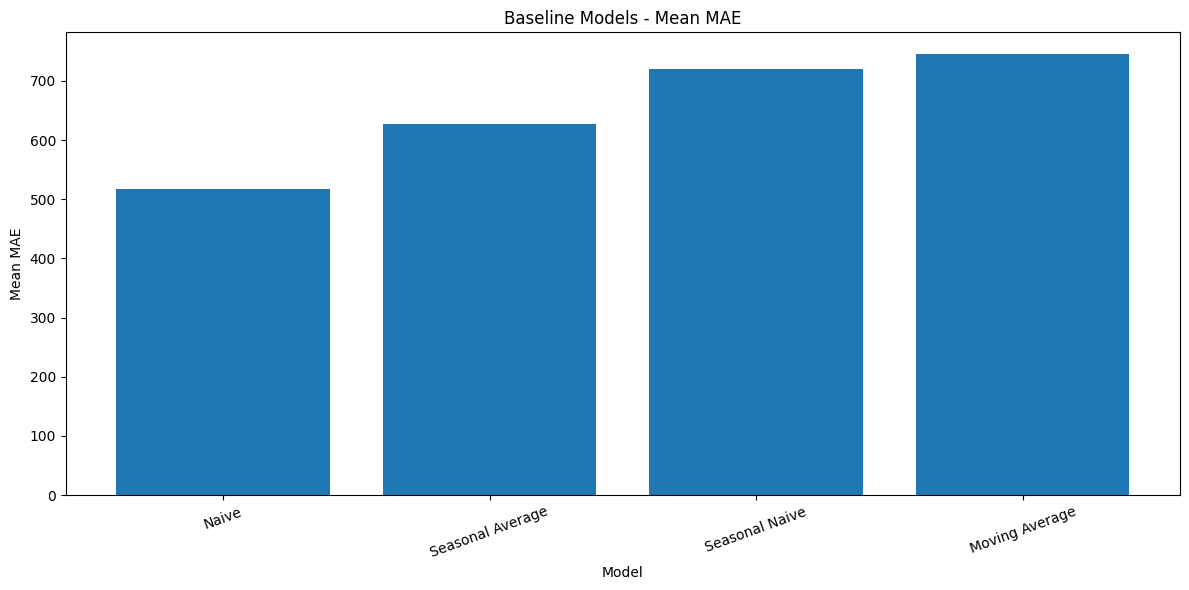

In [46]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    mean_absolute_percentage_error
)


# ============================================================
# BASELINE DATA
# ============================================================

baseline_df = daily_sales[["ds", "y"]].copy()

baseline_df["ds"] = pd.to_datetime(
    baseline_df["ds"]
)

baseline_df["y"] = pd.to_numeric(
    baseline_df["y"],
    errors="coerce"
)

baseline_df = (
    baseline_df
    .dropna(subset=["ds", "y"])
    .sort_values("ds")
    .reset_index(drop=True)
)


print("=" * 70)
print("BASELINE DATA")
print("=" * 70)

print(baseline_df.head())

print("\nShape:", baseline_df.shape)

print(
    "\nDate Range:",
    baseline_df["ds"].min(),
    "→",
    baseline_df["ds"].max()
)

print(
    "\nZero-sales days:",
    (baseline_df["y"] == 0).sum()
)


# ============================================================
# MASE FUNCTION
# ============================================================

def mase(y_true, y_pred, y_train, seasonality=1):

    naive_errors = np.abs(
        y_train[seasonality:] - y_train[:-seasonality]
    )

    scale = np.mean(naive_errors)

    if scale == 0:
        return np.nan

    return mean_absolute_error(
        y_true,
        y_pred
    ) / scale


# ============================================================
# TIME-SERIES CROSS-VALIDATION
# ============================================================

tscv = TimeSeriesSplit(
    n_splits=5
)

MA_WINDOW = 7

SEASONAL_AVG_WEEKS = 4

results = []


for fold, (train_idx, val_idx) in enumerate(
    tscv.split(baseline_df),
    1
):

    train = baseline_df.iloc[train_idx].copy()

    validation = baseline_df.iloc[val_idx].copy()

    print("\n" + "=" * 70)
    print(f"FOLD {fold}")
    print("=" * 70)

    print(
        "Train:",
        train["ds"].min(),
        "→",
        train["ds"].max()
    )

    print(
        "Validation:",
        validation["ds"].min(),
        "→",
        validation["ds"].max()
    )

    y_true = validation["y"].values


    # ========================================================
    # 1. NAIVE
    # ========================================================

    naive_predictions = []

    previous_value = train["y"].iloc[-1]

    for _ in validation["y"]:

        naive_predictions.append(
            previous_value
        )


    naive_predictions = np.array(
        naive_predictions
    )


    # ========================================================
    # 2. SEASONAL NAIVE
    # ========================================================

    seasonal_naive_predictions = []

    history = train["y"].tolist()

    for _ in validation["y"]:

        if len(history) >= 7:

            prediction = history[-7]

        else:

            prediction = history[-1]

        seasonal_naive_predictions.append(
            prediction
        )

        # Recursive forecasting:
        # use prediction, not actual value
        history.append(prediction)


    seasonal_naive_predictions = np.array(
        seasonal_naive_predictions
    )


    # ========================================================
    # 3. MOVING AVERAGE
    # ========================================================

    moving_average_predictions = []

    history = train["y"].tolist()

    for _ in validation["y"]:

        recent_values = history[-MA_WINDOW:]

        prediction = np.mean(
            recent_values
        )

        moving_average_predictions.append(
            prediction
        )

        # Recursive forecasting:
        # use prediction, not actual value
        history.append(prediction)


    moving_average_predictions = np.array(
        moving_average_predictions
    )


    # ========================================================
    # 4. SEASONAL AVERAGE
    # ========================================================

    seasonal_average_predictions = []

    history = train["y"].tolist()

    for _ in validation["y"]:

        if len(history) >= 7:

            same_weekday_values = history[-7::-7]

            same_weekday_values = (
                same_weekday_values[
                    :SEASONAL_AVG_WEEKS
                ]
            )

            prediction = np.mean(
                same_weekday_values
            )

        else:

            prediction = np.mean(
                history
            )

        seasonal_average_predictions.append(
            prediction
        )

        # Recursive forecasting:
        # use prediction, not actual value
        history.append(prediction)


    seasonal_average_predictions = np.array(
        seasonal_average_predictions
    )


    # ========================================================
    # COLLECT PREDICTIONS
    # ========================================================

    predictions = {

        "Naive": naive_predictions,

        "Seasonal Naive": seasonal_naive_predictions,

        "Moving Average": moving_average_predictions,

        "Seasonal Average": seasonal_average_predictions

    }


    # ========================================================
    # EVALUATION
    # ========================================================

    for model_name, y_pred in predictions.items():

        mae = mean_absolute_error(
            y_true,
            y_pred
        )

        rmse = root_mean_squared_error(
            y_true,
            y_pred
        )

        mase_score = mase(
            y_true,
            y_pred,
            train["y"].values,
            seasonality=1
        )


        # MAPE is not reliable when actual values contain zero
        if np.any(y_true == 0):

            mape = np.nan

        else:

            mape = mean_absolute_percentage_error(
                y_true,
                y_pred
            )


        results.append({

            "Model": model_name,

            "Fold": fold,

            "MAE": mae,

            "RMSE": rmse,

            "MASE": mase_score,

            "MAPE": mape

        })


        if not np.isnan(mape):

            print(
                f"{model_name:20s} | "
                f"MAE: {mae:.4f} | "
                f"RMSE: {rmse:.4f} | "
                f"MASE: {mase_score:.4f} | "
                f"MAPE: {mape:.4%}"
            )

        else:

            print(
                f"{model_name:20s} | "
                f"MAE: {mae:.4f} | "
                f"RMSE: {rmse:.4f} | "
                f"MASE: {mase_score:.4f} | "
                f"MAPE: N/A"
            )


# ============================================================
# BASELINE CROSS-VALIDATION RESULTS
# ============================================================

results_df = pd.DataFrame(
    results
)


print("\n" + "=" * 70)
print("BASELINE CROSS-VALIDATION RESULTS")
print("=" * 70)

print(results_df)


# ============================================================
# AVERAGE PERFORMANCE
# ============================================================

average_results = (
    results_df
    .groupby("Model")[
        ["MAE", "RMSE", "MASE", "MAPE"]
    ]
    .mean()
    .reset_index()
)


print("\n" + "=" * 70)
print("AVERAGE BASELINE PERFORMANCE")
print("=" * 70)

print(average_results)


# ============================================================
# RANKING
# ============================================================

average_results_sorted = (
    average_results
    .sort_values("MAE")
    .reset_index(drop=True)
)


print("\n" + "=" * 70)
print("BASELINE MODELS RANKING")
print("=" * 70)

print(average_results_sorted)


# ============================================================
# BEST BASELINE
# ============================================================

best_baseline = (
    average_results_sorted.iloc[0]
)


print("\n" + "=" * 70)
print("BEST BASELINE MODEL")
print("=" * 70)

print(
    "Model:",
    best_baseline["Model"]
)

print(
    f"Mean MAE: "
    f"{best_baseline['MAE']:.4f}"
)

print(
    f"Mean RMSE: "
    f"{best_baseline['RMSE']:.4f}"
)

print(
    f"Mean MASE: "
    f"{best_baseline['MASE']:.4f}"
)


if pd.notna(best_baseline["MAPE"]):

    print(
        f"Mean MAPE: "
        f"{best_baseline['MAPE']:.4%}"
    )

else:

    print("Mean MAPE: N/A")


# ============================================================
# VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    average_results_sorted["Model"],
    average_results_sorted["MAE"]
)

plt.title(
    "Baseline Models - Mean MAE"
)

plt.xlabel("Model")

plt.ylabel("Mean MAE")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

def drift_forecast(train, horizon):
    slope = (train.iloc[-1] - train.iloc[0]) / (len(train) - 1)
    return np.array([
        train.iloc[-1] + slope * i
        for i in range(1, horizon + 1)
    ])

In [47]:
from prophet import Prophet

daily_sales["ds"] = pd.to_datetime(daily_sales["ds"])

daily_sales["y"] = pd.to_numeric(
    daily_sales["y"],
    errors="coerce"
)

prophet_df = (
    daily_sales
    .dropna(subset=["ds", "y"])
    .sort_values("ds")
    .reset_index(drop=True)
)


print("=" * 60)
print("PROPHET DATA")
print("=" * 60)

print(prophet_df.head())
print("\nShape:", prophet_df.shape)

print(
    "\nDate Range:",
    prophet_df["ds"].min(),
    "→",
    prophet_df["ds"].max()
)

print(
    "\nZero-sales days:",
    (prophet_df["y"] == 0).sum()
)

tscv = TimeSeriesSplit(n_splits=5)

def evaluate_prophet(weekly_seasonality):

    results = []

    for fold, (train_idx, val_idx) in enumerate(
        tscv.split(prophet_df), 1
    ):

        train_fold = prophet_df.iloc[train_idx].copy()
        validation_fold = prophet_df.iloc[val_idx].copy()

        print("\n" + "=" * 60)
        print(
            f"PROPHET | Weekly Seasonality = "
            f"{weekly_seasonality} | FOLD {fold}"
        )
        print("=" * 60)

        print(
            "Train:",
            train_fold["ds"].min(),
            "→",
            train_fold["ds"].max()
        )

        print(
            "Validation:",
            validation_fold["ds"].min(),
            "→",
            validation_fold["ds"].max()
        )

        model = Prophet(
            yearly_seasonality=False,
            weekly_seasonality=weekly_seasonality,
            daily_seasonality=False
        )

        model.fit(train_fold)

        forecast = model.predict(
            validation_fold[["ds"]]
        )

        y_true = validation_fold["y"]
        y_pred = forecast["yhat"]

        mae = mean_absolute_error(
            y_true,
            y_pred
        )

        rmse = root_mean_squared_error(
            y_true,
            y_pred
        )
        if (y_true == 0).any():

            mape = None

            print(
                "Warning: MAPE skipped because "
                "validation contains zero-sales days."
            )

        else:

            mape = mean_absolute_percentage_error(
                y_true,
                y_pred
            )

        results.append({

            "Model": (
                "Prophet + Weekly"
                if weekly_seasonality
                else
                "Prophet - Weekly"
            ),

            "Weekly": weekly_seasonality,

            "Fold": fold,

            "MAE": mae,

            "RMSE": rmse,

            "MAPE": mape

        })

        print(f"MAE  : {mae:.4f}")

        print(f"RMSE : {rmse:.4f}")

        if mape is not None:
            print(f"MAPE : {mape:.4%}")


    return pd.DataFrame(results)

results_without_weekly = evaluate_prophet(
    weekly_seasonality=False
)

results_with_weekly = evaluate_prophet(
    weekly_seasonality=True
)

results_df = pd.concat(
    [
        results_without_weekly,
        results_with_weekly
    ],
    ignore_index=True
)


print("\n" + "=" * 60)
print("ALL CROSS-VALIDATION RESULTS")
print("=" * 60)

print(results_df)

average_results = (
    results_df
    .groupby(["Model", "Weekly"])[
        ["MAE", "RMSE", "MAPE"]
    ]
    .mean()
    .reset_index()
)


print("\n" + "=" * 60)
print("AVERAGE CROSS-VALIDATION RESULTS")
print("=" * 60)

print(average_results)

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

for _, row in average_results.iterrows():

    print(f"\n{row['Model']}")

    print(f"Mean MAE  : {row['MAE']:.4f}")

    print(f"Mean RMSE : {row['RMSE']:.4f}")

    if pd.notna(row["MAPE"]):
        print(f"Mean MAPE : {row['MAPE']:.4%}")

best_model_row = average_results.loc[
    average_results["MAE"].idxmin()
]

best_weekly = bool(
    best_model_row["Weekly"]
)


print("\n" + "=" * 60)
print("BEST PROPHET CONFIGURATION")
print("=" * 60)

print(
    "Model:",
    best_model_row["Model"]
)

print(
    "Weekly Seasonality:",
    best_weekly
)

print(
    "Mean MAE:",
    best_model_row["MAE"]
)

print(
    "Mean RMSE:",
    best_model_row["RMSE"]
)

if pd.notna(best_model_row["MAPE"]):
    print(
        "Mean MAPE:",
        best_model_row["MAPE"]
    )

final_model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=best_weekly,
    daily_seasonality=False
)

final_model.fit(prophet_df)

future = final_model.make_future_dataframe(
    periods=30,
    freq="D"
)

forecast = final_model.predict(
    future
)

15:45:51 - cmdstanpy - INFO - Chain [1] start processing


PROPHET DATA
          ds       y
0 2023-01-01 2508.20
1 2023-01-02 2403.35
2 2023-01-03 2565.00
3 2023-01-04 2220.10
4 2023-01-05 2418.85

Shape: (181, 2)

Date Range: 2023-01-01 00:00:00 → 2023-06-30 00:00:00

Zero-sales days: 0

PROPHET | Weekly Seasonality = False | FOLD 1
Train: 2023-01-01 00:00:00 → 2023-01-31 00:00:00
Validation: 2023-02-01 00:00:00 → 2023-03-02 00:00:00


15:45:51 - cmdstanpy - INFO - Chain [1] done processing
15:45:51 - cmdstanpy - INFO - Chain [1] start processing


MAE  : 219.7178
RMSE : 255.8902
MAPE : 8.1819%

PROPHET | Weekly Seasonality = False | FOLD 2
Train: 2023-01-01 00:00:00 → 2023-03-02 00:00:00
Validation: 2023-03-03 00:00:00 → 2023-04-01 00:00:00


15:45:51 - cmdstanpy - INFO - Chain [1] done processing
15:45:51 - cmdstanpy - INFO - Chain [1] start processing


...

MAE  : 381.2712
RMSE : 434.0796
MAPE : 11.4919%

PROPHET | Weekly Seasonality = True | FOLD 3
Train: 2023-01-01 00:00:00 → 2023-04-01 00:00:00
Validation: 2023-04-02 00:00:00 → 2023-05-01 00:00:00


15:45:53 - cmdstanpy - INFO - Chain [1] done processing
15:45:53 - cmdstanpy - INFO - Chain [1] start processing
15:45:53 - cmdstanpy - INFO - Chain [1] done processing


MAE  : 607.3440
RMSE : 682.7880
MAPE : 14.6364%

PROPHET | Weekly Seasonality = True | FOLD 4
Train: 2023-01-01 00:00:00 → 2023-05-01 00:00:00
Validation: 2023-05-02 00:00:00 → 2023-05-31 00:00:00
MAE  : 681.4971
RMSE : 754.5888
MAPE : 13.1201%

PROPHET | Weekly Seasonality = True | FOLD 5
Train: 2023-01-01 00:00:00 → 2023-05-31 00:00:00
Validation: 2023-06-01 00:00:00 → 2023-06-30 00:00:00


15:45:53 - cmdstanpy - INFO - Chain [1] start processing
15:45:53 - cmdstanpy - INFO - Chain [1] done processing
15:45:54 - cmdstanpy - INFO - Chain [1] start processing
15:45:54 - cmdstanpy - INFO - Chain [1] done processing


MAE  : 420.9522
RMSE : 569.3048
MAPE : 8.1255%

ALL CROSS-VALIDATION RESULTS
              Model  Weekly  Fold    MAE   RMSE  MAPE
0  Prophet - Weekly   False     1 219.72 255.89  0.08
1  Prophet - Weekly   False     2 380.82 431.61  0.11
2  Prophet - Weekly   False     3 624.68 706.49  0.15
3  Prophet - Weekly   False     4 669.62 746.71  0.13
4  Prophet - Weekly   False     5 422.36 568.99  0.08
5  Prophet + Weekly    True     1 243.84 283.45  0.09
6  Prophet + Weekly    True     2 381.27 434.08  0.11
7  Prophet + Weekly    True     3 607.34 682.79  0.15
8  Prophet + Weekly    True     4 681.50 754.59  0.13
9  Prophet + Weekly    True     5 420.95 569.30  0.08

AVERAGE CROSS-VALIDATION RESULTS
              Model  Weekly    MAE   RMSE  MAPE
0  Prophet + Weekly    True 466.98 544.84  0.11
1  Prophet - Weekly   False 463.44 541.94  0.11

MODEL COMPARISON

Prophet + Weekly
Mean MAE  : 466.9802
Mean RMSE : 544.8425
Mean MAPE : 11.2764%

Prophet - Weekly
Mean MAE  : 463.4376
Mean RMSE : 5

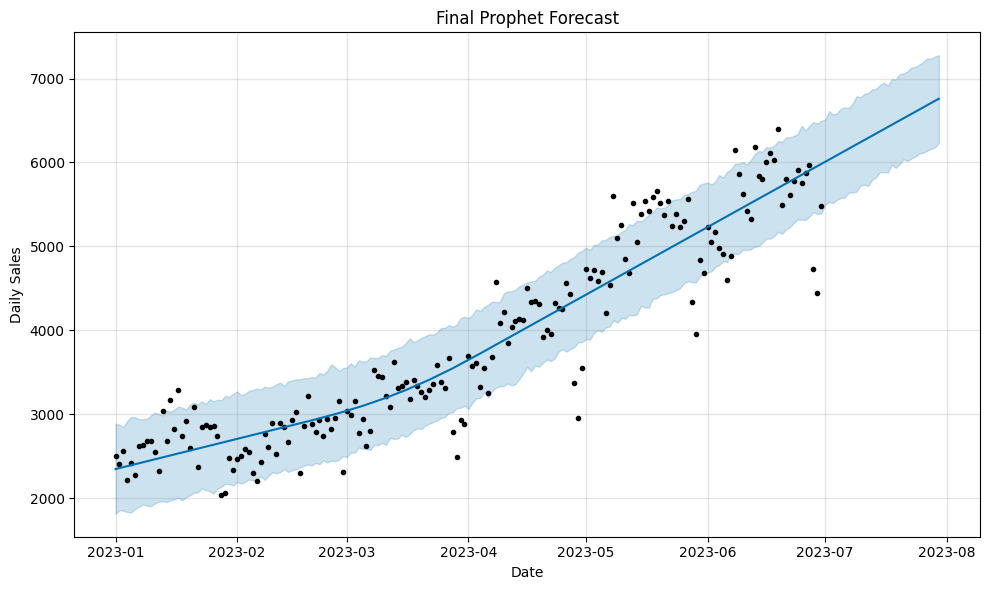

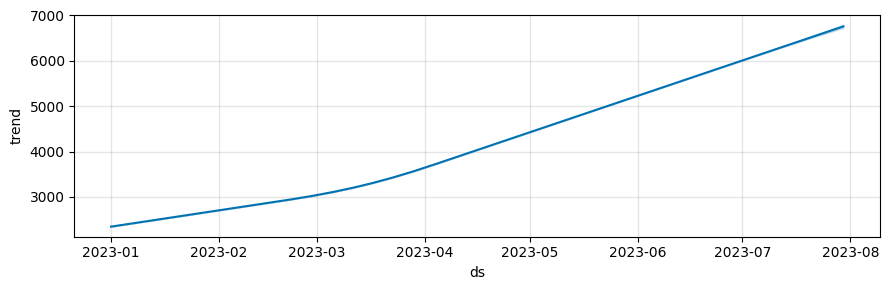

In [48]:
fig = final_model.plot(forecast)

plt.title("Final Prophet Forecast")
plt.xlabel("Date")
plt.ylabel("Daily Sales")

plt.tight_layout()
plt.show()

fig = final_model.plot_components(
    forecast
)

plt.tight_layout()
plt.show()

In [49]:
print("\n" + "=" * 60)
print("FINAL FORECAST")
print("=" * 60)
print(
    forecast[
        [
            "ds",
            "yhat",
            "yhat_lower",
            "yhat_upper"
        ]
    ].tail(30)
)


FINAL FORECAST
            ds    yhat  yhat_lower  yhat_upper
181 2023-07-01 6008.10     5494.77     6507.23
182 2023-07-02 6034.03     5530.97     6612.26
183 2023-07-03 6059.95     5515.89     6573.19
184 2023-07-04 6085.88     5554.44     6585.97
185 2023-07-05 6111.81     5578.90     6641.45
186 2023-07-06 6137.73     5583.00     6657.68
187 2023-07-07 6163.66     5640.98     6650.40
188 2023-07-08 6189.59     5643.86     6699.71
189 2023-07-09 6215.51     5653.12     6789.53
190 2023-07-10 6241.44     5725.55     6778.14
191 2023-07-11 6267.37     5736.11     6818.89
192 2023-07-12 6293.29     5721.15     6829.53
193 2023-07-13 6319.22     5795.05     6871.41
194 2023-07-14 6345.15     5825.68     6877.35
195 2023-07-15 6371.07     5886.00     6925.37
196 2023-07-16 6397.00     5882.22     6951.18
197 2023-07-17 6422.93     5880.32     6917.23
198 2023-07-18 6448.86     5973.07     6994.70
199 2023-07-19 6474.78     5936.24     6990.08
200 2023-07-20 6500.71     5978.33     7052.

In [50]:
daily_sales["month"] = daily_sales["ds"].dt.month
daily_sales["day_of_week"] = daily_sales["ds"].dt.dayofweek

daily_sales["is_weekend"] = (
    daily_sales["day_of_week"].isin([4, 5]).astype(int)
)

daily_sales["revenue_lag_1"] = daily_sales["y"].shift(1)

daily_sales['revenue_lag_7'] = daily_sales["y"].shift(7)

daily_sales["revenue_rolling_mean_30"] = (
    daily_sales["y"]
    .shift(1)
    .rolling(30)
    .mean()
)

daily_sales["revenue_rolling_std_30"] = (
    daily_sales["y"]
    .shift(1)
    .rolling(30)
    .std()
)

daily_sales["dow_sin"] = np.sin(
    2 * np.pi * daily_sales["day_of_week"] / 7
)

daily_sales["dow_cos"] = np.cos(
    2 * np.pi * daily_sales["day_of_week"] / 7
)

In [51]:
daily_sales 

,ds,y,month,day_of_week,is_weekend,revenue_lag_1,revenue_lag_7,revenue_rolling_mean_30,revenue_rolling_std_30,dow_sin,dow_cos
0,2023-01-01,2508.20,1,6,0,NaN,NaN,NaN,NaN,-0.78,0.62
1,2023-01-02,2403.35,1,0,0,2508.20,NaN,NaN,NaN,0.00,1.00
2,2023-01-03,2565.00,1,1,0,2403.35,NaN,NaN,NaN,0.78,0.62
3,2023-01-04,2220.10,1,2,0,2565.00,NaN,NaN,NaN,0.97,-0.22
4,2023-01-05,2418.85,1,3,0,2220.10,NaN,NaN,NaN,0.43,-0.90
...,...,...,...,...,...,...,...,...,...,...,...
176,2023-06-26,5875.90,6,0,0,5754.85,6403.91,5445.01,598.18,0.00,1.00
177,2023-06-27,5975.65,6,1,0,5875.90,5494.66,5455.57,603.04,0.78,0.62
178,2023-06-28,4728.90,6,2,0,5975.65,5808.38,5510.13,571.74,0.97,-0.22
179,2023-06-29,4450.75,6,3,0,4728.90,5615.10,5535.78,514.14,0.43,-0.90


In [52]:
print("=" * 60)
print("Missing Values Summary")
print("=" * 60)

def missing_values_report(daily_sales):
    report = pd.DataFrame({
        "missing_count": daily_sales.isna().sum(),
        "missing_percentage": daily_sales.isna().mean() * 100
    })

    report = report.sort_values(
        "missing_percentage",
        ascending=False
    )

    return report


report = missing_values_report(daily_sales)

print(report)

Missing Values Summary
                         missing_count  missing_percentage
revenue_rolling_std_30              30               16.57
revenue_rolling_mean_30             30               16.57
revenue_lag_7                        7                3.87
revenue_lag_1                        1                0.55
month                                0                0.00
ds                                   0                0.00
y                                    0                0.00
day_of_week                          0                0.00
is_weekend                           0                0.00
dow_sin                              0                0.00
dow_cos                              0                0.00


In [53]:
daily_sales = daily_sales.dropna(
    subset=[
        "revenue_lag_1",
        "revenue_lag_7",
        "revenue_rolling_mean_30",
        "revenue_rolling_std_30"
    ]
).reset_index(drop=True)

In [54]:
daily_sales.shape

(151, 11)

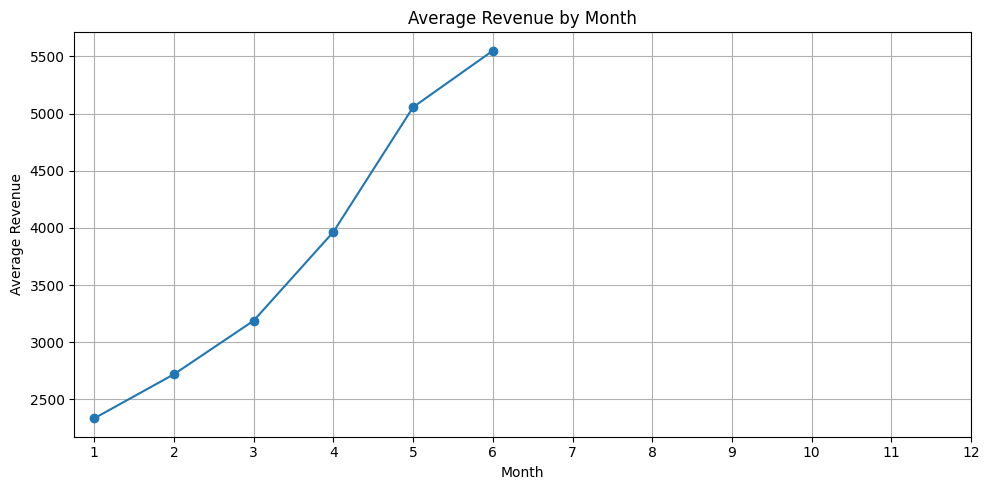

In [55]:
monthly_avg_1 = (
    daily_sales.groupby("month")["y"]
    .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_avg_1.index,
    monthly_avg_1.values,
    marker="o",
)

plt.title("Average Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Average Revenue")

plt.xticks(range(1, 13))
plt.grid(True)

plt.tight_layout()
plt.show()

In [56]:
daily_sales

,ds,y,month,day_of_week,is_weekend,revenue_lag_1,revenue_lag_7,revenue_rolling_mean_30,revenue_rolling_std_30,dow_sin,dow_cos
0,2023-01-31,2334.13,1,1,0,2476.41,2868.95,2644.79,306.06,0.78,0.62
1,2023-02-01,2466.30,2,2,0,2334.13,2846.55,2638.98,310.36,0.97,-0.22
2,2023-02-02,2506.90,2,3,0,2466.30,2863.03,2641.08,308.92,0.43,-0.90
3,2023-02-03,2591.45,2,4,1,2506.90,2742.10,2639.15,309.59,-0.43,-0.90
4,2023-02-04,2551.70,2,5,1,2591.45,2037.10,2651.52,299.52,-0.97,-0.22
...,...,...,...,...,...,...,...,...,...,...,...
146,2023-06-26,5875.90,6,0,0,5754.85,6403.91,5445.01,598.18,0.00,1.00
147,2023-06-27,5975.65,6,1,0,5875.90,5494.66,5455.57,603.04,0.78,0.62
148,2023-06-28,4728.90,6,2,0,5975.65,5808.38,5510.13,571.74,0.97,-0.22
149,2023-06-29,4450.75,6,3,0,4728.90,5615.10,5535.78,514.14,0.43,-0.90


DAILY DATA
Rows       : 151
Start date : 2023-01-31
End date   : 2023-06-30


,ds,y
0,2023-01-31,2334.13
1,2023-02-01,2466.30
2,2023-02-02,2506.90
3,2023-02-03,2591.45
4,2023-02-04,2551.70



FEATURES
Number of features: 8
Features: ['is_weekend', 'revenue_lag_1', 'revenue_lag_7', 'revenue_lag_14', 'revenue_rolling_mean_7', 'revenue_rolling_mean_30', 'dow_sin', 'dow_cos']
X shape: (121, 8)
y shape: (121,)

VALIDATION SETUP
Training observations : 91
Final holdout         : 30
CV splits             : 2
Forecast horizon      : 30 days

Final holdout period: 2023-06-01 to 2023-06-30

BASIC ML EVALUATION
Evaluating: Linear Regression
Evaluating: Random Forest
Evaluating: XGBoost
Evaluating: LightGBM
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 31, number of used features: 0
[LightGBM] [Info] Start training from score 3209.494527
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split r

,Model,CV_MAE,CV_RMSE,CV_MAPE,CV_MASE
0,Linear Regression,667.03,765.61,0.15,2.60
1,LightGBM,834.71,931.43,0.18,3.23
2,XGBoost,865.58,952.88,0.19,3.35
3,Random Forest,874.73,962.53,0.19,3.38



MODELS SELECTED FOR TUNING
['LightGBM', 'XGBoost']

HYPERPARAMETER TUNING

Tuning LightGBM...
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 31, number of used features: 0
[LightGBM] [Info] Start training from score 3209.494527
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requ

,Model,CV_MAE
0,Linear Regression,667.03
1,LightGBM Tuned,833.22
2,LightGBM,834.71
3,XGBoost Tuned,837.87
4,XGBoost,865.58
5,Random Forest,874.73



SELECTED MODEL
Best model: Linear Regression
CV MAE: 667.03

FINAL 30-DAY HOLDOUT
Holdout period: 2023-06-01 to 2023-06-30


,Model,MAE,RMSE,MAPE,MASE
0,Linear Regression,439.42,536.40,0.08,1.53



FINAL MODEL RETRAINED
Model: Linear Regression
Training observations: 121


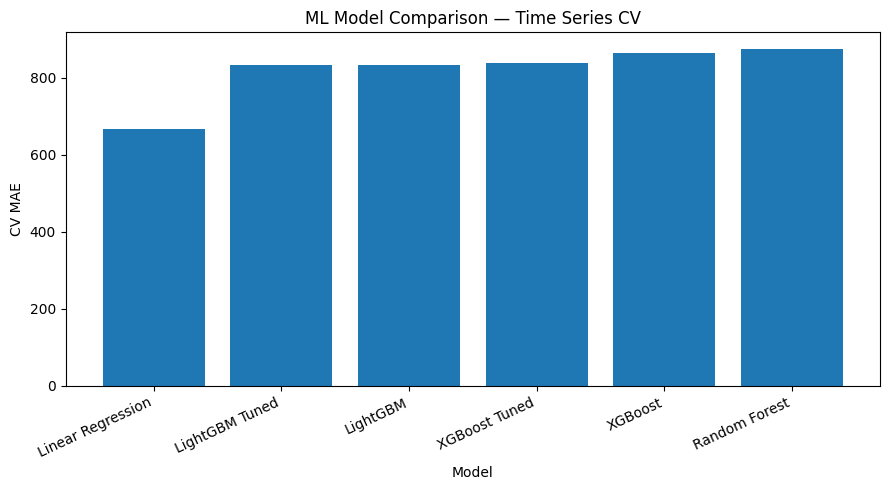


30-DAY FUTURE FORECAST


,ds,yhat
0,2023-07-01,5581.96
1,2023-07-02,5627.38
2,2023-07-03,5727.75
3,2023-07-04,5736.94
4,2023-07-05,5612.35
5,2023-07-06,5588.05
6,2023-07-07,5749.33
7,2023-07-08,5780.73
8,2023-07-09,5809.90
9,2023-07-10,5908.81


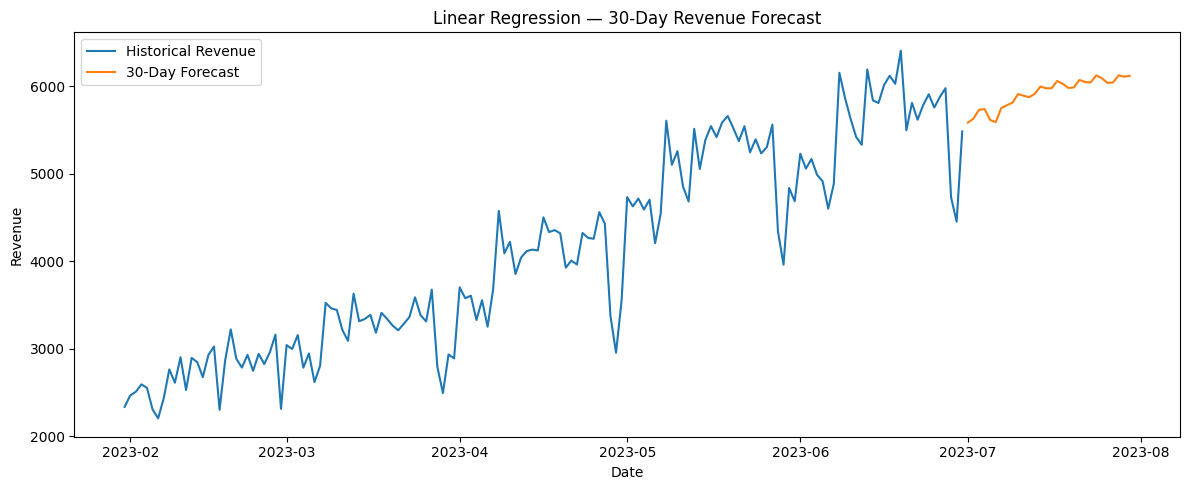


FINAL FORECASTING SUMMARY
Best Model      : Linear Regression
CV MAE          : 667.03
Holdout MAE     : 439.42
Holdout RMSE    : 536.40
Holdout MAPE    : 7.82%
Holdout MASE    : 1.53
Forecast Horizon: 30 days


In [57]:
# ============================================================
# 1. IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, ParameterSampler
from sklearn.base import clone
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    mean_absolute_percentage_error
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# ============================================================
# 2. CONFIGURATION
# ============================================================

RANDOM_STATE = 42

FORECAST_HORIZON = 30
N_SPLITS = 2

WEEKEND_DAYS = [5, 6]

FEATURES = [
    "is_weekend",
    "revenue_lag_1",
    "revenue_lag_7",
    "revenue_lag_14",
    "revenue_rolling_mean_7",
    "revenue_rolling_mean_30",
    "dow_sin",
    "dow_cos"
]


# ============================================================
# 3. PREPARE DAILY DATA
# ============================================================

ml_df = daily_sales[["ds", "y"]].copy()

ml_df["ds"] = pd.to_datetime(ml_df["ds"])

ml_df = (
    ml_df
    .sort_values("ds")
    .drop_duplicates("ds")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Validate target
# ------------------------------------------------------------

if ml_df["y"].isna().any():
    raise ValueError("Revenue contains missing values.")

if (ml_df["y"] < 0).any():
    raise ValueError("Revenue contains negative values.")


# ------------------------------------------------------------
# Validate daily frequency
# ------------------------------------------------------------

expected_dates = pd.date_range(
    start=ml_df["ds"].min(),
    end=ml_df["ds"].max(),
    freq="D"
)

if len(expected_dates) != len(ml_df):
    missing_dates = expected_dates.difference(ml_df["ds"])

    raise ValueError(
        f"Missing {len(missing_dates)} calendar days in daily data."
    )


print("=" * 70)
print("DAILY DATA")
print("=" * 70)

print("Rows       :", len(ml_df))
print("Start date :", ml_df["ds"].min().date())
print("End date   :", ml_df["ds"].max().date())

display(ml_df.head())


# ============================================================
# 4. FEATURE ENGINEERING
# ============================================================

def create_features(data):
    """
    Create forecasting features using only historical information.
    """

    df = data.copy()

    day_of_week = df["ds"].dt.dayofweek

    df["is_weekend"] = (
        day_of_week
        .isin(WEEKEND_DAYS)
        .astype(int)
    )

    # Lag features
    df["revenue_lag_1"] = df["y"].shift(1)
    df["revenue_lag_7"] = df["y"].shift(7)
    df["revenue_lag_14"] = df["y"].shift(14)

    # Shift first to prevent target leakage
    shifted_y = df["y"].shift(1)

    df["revenue_rolling_mean_7"] = (
        shifted_y
        .rolling(7)
        .mean()
    )

    df["revenue_rolling_mean_30"] = (
        shifted_y
        .rolling(30)
        .mean()
    )

    # Cyclical day-of-week features
    df["dow_sin"] = np.sin(
        2 * np.pi * day_of_week / 7
    )

    df["dow_cos"] = np.cos(
        2 * np.pi * day_of_week / 7
    )

    return df


ml_features = create_features(ml_df)

ml_features = (
    ml_features
    .dropna(subset=FEATURES)
    .reset_index(drop=True)
)


X = ml_features[FEATURES].copy()
y = ml_features["y"].copy()


print("\n" + "=" * 70)
print("FEATURES")
print("=" * 70)

print("Number of features:", len(FEATURES))
print("Features:", FEATURES)
print("X shape:", X.shape)
print("y shape:", y.shape)


# ============================================================
# 5. FINAL HOLDOUT + TIME SERIES CV
# ============================================================

holdout_size = FORECAST_HORIZON

if len(X) <= (
    N_SPLITS * FORECAST_HORIZON + FORECAST_HORIZON
):
    raise ValueError(
        "Not enough observations for the selected "
        "CV and final holdout configuration."
    )


# ------------------------------------------------------------
# Final 30-day holdout
# ------------------------------------------------------------

X_train = X.iloc[:-holdout_size].copy()
X_holdout = X.iloc[-holdout_size:].copy()

y_train = y.iloc[:-holdout_size].copy()
y_holdout = y.iloc[-holdout_size:].copy()

holdout_dates = (
    ml_features
    .iloc[-holdout_size:]["ds"]
    .copy()
)


# ------------------------------------------------------------
# Time-series cross-validation
# ------------------------------------------------------------

tscv = TimeSeriesSplit(
    n_splits=N_SPLITS,
    test_size=FORECAST_HORIZON
)


print("\n" + "=" * 70)
print("VALIDATION SETUP")
print("=" * 70)

print("Training observations :", len(X_train))
print("Final holdout         :", len(X_holdout))
print("CV splits             :", N_SPLITS)
print("Forecast horizon      :", FORECAST_HORIZON, "days")

print(
    "\nFinal holdout period:",
    holdout_dates.min().date(),
    "to",
    holdout_dates.max().date()
)


# ============================================================
# 6. METRICS
# ============================================================

def calculate_metrics(y_true, y_pred, y_train):
    """
    Calculate forecasting accuracy metrics.

    MAE  : primary metric
    RMSE : penalizes large errors
    MAPE : additional percentage-based metric
    MASE : scale-free comparison against naive forecasting
    """

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_train = np.asarray(y_train)

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = root_mean_squared_error(
        y_true,
        y_pred
    )

    non_zero = y_true != 0

    if non_zero.any():
        mape = mean_absolute_percentage_error(
            y_true[non_zero],
            y_pred[non_zero]
        )
    else:
        mape = np.nan

    naive_errors = np.abs(
        y_train[1:] - y_train[:-1]
    )

    scale = naive_errors.mean()

    if scale == 0:
        mase = np.nan
    else:
        mase = mae / scale

    return mae, rmse, mape, mase


# ============================================================
# 7. ML MODELS
# ============================================================

models = {

    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_features="sqrt",
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

}


# ============================================================
# 8. RECURSIVE FEATURE CREATION
# ============================================================

def build_forecast_features(history, current_date):
    """
    Build features for one future day.

    Only historical actual/predicted revenue is used.
    """

    day_of_week = current_date.dayofweek

    lag_1 = history.iloc[-1]
    lag_7 = history.iloc[-7]
    lag_14 = history.iloc[-14]

    rolling_mean_7 = (
        history.iloc[-7:].mean()
    )

    rolling_mean_30 = (
        history.iloc[-30:].mean()
    )

    features = pd.DataFrame({
        "is_weekend": [
            int(day_of_week in WEEKEND_DAYS)
        ],

        "revenue_lag_1": [
            lag_1
        ],

        "revenue_lag_7": [
            lag_7
        ],

        "revenue_lag_14": [
            lag_14
        ],

        "revenue_rolling_mean_7": [
            rolling_mean_7
        ],

        "revenue_rolling_mean_30": [
            rolling_mean_30
        ],

        "dow_sin": [
            np.sin(
                2 * np.pi * day_of_week / 7
            )
        ],

        "dow_cos": [
            np.cos(
                2 * np.pi * day_of_week / 7
            )
        ]
    })

    return features[FEATURES]


# ============================================================
# 9. RECURSIVE FORECASTING
# ============================================================

def recursive_forecast(
    model,
    train_history,
    forecast_dates
):
    """
    Generate recursive multi-step forecasts.

    Each prediction is fed back into the history
    for the next forecasting step.
    """

    history = pd.Series(
        train_history.values,
        index=train_history.index,
        dtype=float
    )

    predictions = []

    for current_date in forecast_dates:

        features = build_forecast_features(
            history,
            current_date
        )

        prediction = model.predict(
            features
        )[0]

        # Revenue cannot be negative
        prediction = max(
            0,
            prediction
        )

        predictions.append(
            prediction
        )

        # Feed prediction into future history
        history.loc[current_date] = prediction

    return np.asarray(predictions)


# ============================================================
# 10. TIME SERIES CV EVALUATION
# ============================================================

def evaluate_model_cv(
    model,
    model_name,
    X_data,
    y_data,
    dates,
    cv
):

    results = []

    for fold, (train_idx, test_idx) in enumerate(
        cv.split(X_data),
        start=1
    ):

        X_fold_train = X_data.iloc[train_idx]
        y_fold_train = y_data.iloc[train_idx]

        X_fold_test = X_data.iloc[test_idx]
        y_fold_test = y_data.iloc[test_idx]

        # Train model
        fitted_model = clone(model)

        fitted_model.fit(
            X_fold_train,
            y_fold_train
        )

        # ----------------------------------------------------
        # Historical revenue before validation period
        # ----------------------------------------------------

        validation_start = dates.iloc[train_idx[-1]]

        history = (
            ml_df.loc[
                ml_df["ds"] <= validation_start,
                ["ds", "y"]
            ]
            .set_index("ds")["y"]
            .sort_index()
        )

        validation_dates = (
            dates.iloc[test_idx]
            .reset_index(drop=True)
        )

        # ----------------------------------------------------
        # Recursive forecasting
        # ----------------------------------------------------

        predictions = recursive_forecast(
            model=fitted_model,
            train_history=history,
            forecast_dates=validation_dates
        )

        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        mae, rmse, mape, mase = calculate_metrics(
            y_true=y_fold_test,
            y_pred=predictions,
            y_train=y_fold_train
        )

        results.append({
            "Model": model_name,
            "Fold": fold,
            "MAE": mae,
            "RMSE": rmse,
            "MAPE": mape,
            "MASE": mase
        })

    return results


# ============================================================
# 11. BASIC MODEL EVALUATION
# ============================================================

basic_results = []

print("\n" + "=" * 70)
print("BASIC ML EVALUATION")
print("=" * 70)

for model_name, model in models.items():

    print(
        f"Evaluating: {model_name}"
    )

    fold_results = evaluate_model_cv(
        model=model,
        model_name=model_name,
        X_data=X_train,
        y_data=y_train,
        dates=ml_features.iloc[:-holdout_size]["ds"],
        cv=tscv
    )

    basic_results.extend(
        fold_results
    )


basic_results_df = pd.DataFrame(
    basic_results
)


# ============================================================
# 12. BASIC MODEL SUMMARY
# ============================================================

basic_summary = (
    basic_results_df
    .groupby("Model")
    .agg(
        CV_MAE=("MAE", "mean"),
        CV_RMSE=("RMSE", "mean"),
        CV_MAPE=("MAPE", "mean"),
        CV_MASE=("MASE", "mean")
    )
    .reset_index()
    .sort_values("CV_MAE")
    .reset_index(drop=True)
)


print("\n" + "=" * 70)
print("BASIC MODEL COMPARISON")
print("=" * 70)

display(
    basic_summary
)


# ============================================================
# 13. SELECT MODELS FOR TUNING
# ============================================================

tuning_spaces = {

    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", 1.0]
    },

    "XGBoost": {
        "n_estimators": [100, 200, 300],
        "learning_rate": [0.03, 0.05, 0.1],
        "max_depth": [3, 4, 5],
        "min_child_weight": [1, 3, 5],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    },

    "LightGBM": {
        "n_estimators": [100, 200, 300],
        "learning_rate": [0.03, 0.05, 0.1],
        "max_depth": [3, 4, 5],
        "min_child_weight": [1, 3, 5],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
        }
    }

tunable_results = (
    basic_summary[
        basic_summary["Model"].isin(
            tuning_spaces.keys()
        )
    ]
    .sort_values("CV_MAE")
)


TOP_MODELS_TO_TUNE = min(
    2,
    len(tunable_results)
)

selected_models = (
    tunable_results
    .head(TOP_MODELS_TO_TUNE)
    ["Model"]
    .tolist()
)


print("\n" + "=" * 70)
print("MODELS SELECTED FOR TUNING")
print("=" * 70)

print(selected_models)


# ============================================================
# 14. HYPERPARAMETER TUNING
# ============================================================

N_ITER_TUNING = 8

tuned_models = {}
tuned_results = []


def tune_model(
    model_name,
    base_model,
    parameter_space,
    n_iter=8
):

    candidates = list(
        ParameterSampler(
            parameter_space,
            n_iter=n_iter,
            random_state=RANDOM_STATE
        )
    )

    best_score = np.inf
    best_params = None

    # Prevent nested CPU overload
    if hasattr(base_model, "n_jobs"):
        base_model.set_params(
            n_jobs=1
        )

    for iteration, params in enumerate(
        candidates,
        start=1
    ):

        candidate = clone(
            base_model
        )

        candidate.set_params(
            **params
        )

        fold_scores = []

        for train_idx, test_idx in tscv.split(
            X_train
        ):

            X_fold_train = X_train.iloc[
                train_idx
            ]

            y_fold_train = y_train.iloc[
                train_idx
            ]

            X_fold_test = X_train.iloc[
                test_idx
            ]

            y_fold_test = y_train.iloc[
                test_idx
            ]

            fitted = clone(
                candidate
            )

            fitted.fit(
                X_fold_train,
                y_fold_train
            )

            validation_start = (
                ml_features.iloc[
                    train_idx[-1]
                ]["ds"]
            )

            history = (
                ml_df.loc[
                    ml_df["ds"] <= validation_start,
                    ["ds", "y"]
                ]
                .set_index("ds")["y"]
                .sort_index()
            )

            validation_dates = (
                ml_features.iloc[
                    test_idx
                ]["ds"]
                .reset_index(drop=True)
            )

            predictions = recursive_forecast(
                model=fitted,
                train_history=history,
                forecast_dates=validation_dates
            )

            fold_mae = mean_absolute_error(
                y_fold_test,
                predictions
            )

            fold_scores.append(
                fold_mae
            )

        cv_mae = np.mean(fold_scores)

        print(
            f"{model_name} | "
            f"{iteration}/{len(candidates)} | "
            f"CV MAE = {cv_mae:.2f}"
        )

        if cv_mae < best_score:

            best_score = cv_mae
            best_params = params

    # Fit best configuration on all training data
    best_model = clone(
        base_model
    )

    best_model.set_params(
        **best_params
    )

    if hasattr(best_model, "n_jobs"):
        best_model.set_params(
            n_jobs=-1
        )

    best_model.fit(
        X_train,
        y_train
    )

    return (
        best_model,
        best_score,
        best_params
    )


print("\n" + "=" * 70)
print("HYPERPARAMETER TUNING")
print("=" * 70)


for model_name in selected_models:

    print(
        f"\nTuning {model_name}..."
    )

    tuned_model, best_score, best_params = (
        tune_model(
            model_name=model_name,
            base_model=models[model_name],
            parameter_space=tuning_spaces[model_name],
            n_iter=N_ITER_TUNING
        )
    )

    tuned_models[
        model_name
    ] = tuned_model

    tuned_results.append({
        "Model": f"{model_name} Tuned",
        "CV_MAE": best_score,
        "Best_Params": best_params
    })


tuned_summary = pd.DataFrame(
    tuned_results
)


# ============================================================
# 15. FINAL MODEL SELECTION
# ============================================================

basic_selection = (
    basic_summary[
        ["Model", "CV_MAE"]
    ]
    .copy()
)

tuned_selection = (
    tuned_summary[
        ["Model", "CV_MAE"]
    ]
    .copy()
)

all_model_results = pd.concat(
    [
        basic_selection,
        tuned_selection
    ],
    ignore_index=True
)

all_model_results = (
    all_model_results
    .sort_values("CV_MAE")
    .reset_index(drop=True)
)


print("\n" + "=" * 70)
print("ALL MODEL RESULTS")
print("=" * 70)

display(
    all_model_results
)


best_model_name = (
    all_model_results.iloc[0]["Model"]
)

best_model_cv_mae = (
    all_model_results.iloc[0]["CV_MAE"]
)


print("\n" + "=" * 70)
print("SELECTED MODEL")
print("=" * 70)

print(
    "Best model:",
    best_model_name
)

print(
    "CV MAE:",
    f"{best_model_cv_mae:.2f}"
)


# ============================================================
# 16. GET FINAL MODEL OBJECT
# ============================================================

if best_model_name.endswith("Tuned"):

    base_name = (
        best_model_name
        .replace(" Tuned", "")
    )

    final_model = clone(
        tuned_models[base_name]
    )

else:

    final_model = clone(
        models[best_model_name]
    )


if hasattr(final_model, "n_jobs"):
    final_model.set_params(
        n_jobs=-1
    )


# ============================================================
# 17. FINAL 30-DAY HOLDOUT
# ============================================================

print("\n" + "=" * 70)
print("FINAL 30-DAY HOLDOUT")
print("=" * 70)


# Train ONLY on pre-holdout data
final_model.fit(
    X_train,
    y_train
)


# History before holdout
holdout_history = (
    ml_df.loc[
        ml_df["ds"] < holdout_dates.min(),
        ["ds", "y"]
    ]
    .set_index("ds")["y"]
    .sort_index()
)


# Recursive holdout forecast
holdout_predictions = recursive_forecast(
    model=final_model,
    train_history=holdout_history,
    forecast_dates=holdout_dates.reset_index(drop=True)
)


# Calculate final holdout metrics
final_mae, final_rmse, final_mape, final_mase = (
    calculate_metrics(
        y_true=y_holdout,
        y_pred=holdout_predictions,
        y_train=y_train
    )
)


final_evaluation = pd.DataFrame({
    "Model": [best_model_name],
    "MAE": [final_mae],
    "RMSE": [final_rmse],
    "MAPE": [final_mape],
    "MASE": [final_mase]
})


print(
    "Holdout period:",
    holdout_dates.min().date(),
    "to",
    holdout_dates.max().date()
)

display(
    final_evaluation
)


# ============================================================
# 18. RETRAIN FINAL MODEL ON ALL AVAILABLE DATA
# ============================================================

final_model.fit(
    X,
    y
)


print("\n" + "=" * 70)
print("FINAL MODEL RETRAINED")
print("=" * 70)

print(
    "Model:",
    best_model_name
)

print(
    "Training observations:",
    len(X)
)


# ============================================================
# 19. FEATURE IMPORTANCE
# ============================================================

if hasattr(
    final_model,
    "feature_importances_"
):

    feature_importance = pd.DataFrame({
        "Feature": FEATURES,
        "Importance":
            final_model.feature_importances_
    })

    feature_importance = (
        feature_importance
        .sort_values(
            "Importance",
            ascending=False
        )
        .reset_index(drop=True)
    )

    print("\n" + "=" * 70)
    print("FEATURE IMPORTANCE")
    print("=" * 70)

    display(
        feature_importance
    )

    plt.figure(
        figsize=(9, 5)
    )

    top_features = (
        feature_importance
        .head(10)
        .sort_values("Importance")
    )

    plt.barh(
        top_features["Feature"],
        top_features["Importance"]
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(
        f"Feature Importance — {best_model_name}"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 20. MODEL COMPARISON
# ============================================================

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    all_model_results["Model"],
    all_model_results["CV_MAE"]
)

plt.ylabel("CV MAE")
plt.xlabel("Model")
plt.title(
    "ML Model Comparison — Time Series CV"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()
plt.show()


# ============================================================
# 21. FUTURE 30-DAY FORECAST
# ============================================================

future_dates = pd.date_range(
    start=ml_df["ds"].max()
          + pd.Timedelta(days=1),
    periods=FORECAST_HORIZON,
    freq="D"
)


# Use all available historical observations
future_history = (
    ml_df
    .set_index("ds")["y"]
    .sort_index()
)


future_predictions = recursive_forecast(
    model=final_model,
    train_history=future_history,
    forecast_dates=future_dates
)


forecast_df = pd.DataFrame({
    "ds": future_dates,
    "yhat": future_predictions
})


# ============================================================
# 22. FORECAST RESULTS
# ============================================================

print("\n" + "=" * 70)
print("30-DAY FUTURE FORECAST")
print("=" * 70)

display(
    forecast_df
)


# ============================================================
# 23. FORECAST VISUALIZATION
# ============================================================

plt.figure(
    figsize=(12, 5)
)

plt.plot(
    ml_df["ds"],
    ml_df["y"],
    label="Historical Revenue"
)

plt.plot(
    forecast_df["ds"],
    forecast_df["yhat"],
    label="30-Day Forecast"
)

plt.xlabel("Date")
plt.ylabel("Revenue")

plt.title(
    f"{best_model_name} — 30-Day Revenue Forecast"
)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 24. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL FORECASTING SUMMARY")
print("=" * 70)

print(
    f"Best Model      : {best_model_name}"
)

print(
    f"CV MAE          : {best_model_cv_mae:.2f}"
)

print(
    f"Holdout MAE     : {final_mae:.2f}"
)

print(
    f"Holdout RMSE    : {final_rmse:.2f}"
)

print(
    f"Holdout MAPE    : {final_mape:.2%}"
)

print(
    f"Holdout MASE    : {final_mase:.2f}"
)

print(
    f"Forecast Horizon: {FORECAST_HORIZON} days"
)

15:53:26 - cmdstanpy - INFO - Chain [1] start processing
15:53:26 - cmdstanpy - INFO - Chain [1] done processing



FINAL MODEL COMPARISON

Training Period: 2023-01-31 to 2023-05-31
Holdout Period : 2023-06-01 to 2023-06-30
Forecast Horizon: 30 days


15:53:26 - cmdstanpy - INFO - Chain [1] start processing
15:53:26 - cmdstanpy - INFO - Chain [1] done processing


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000179 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 176
[LightGBM] [Info] Number of data points in the train set: 91, number of used features: 8
[LightGBM] [Info] Start training from score 4082.013972
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

,Rank,Model,Group,MAE,RMSE,MAPE,MAE Improvement vs Best Baseline
0,1,Prophet - No Weekly,Prophet,402.33,544.73,0.08,30.43
1,2,Prophet + Weekly,Prophet,405.83,553.51,0.08,29.82
2,3,Linear Regression,Basic ML,447.18,544.04,0.08,22.67
3,4,LightGBM Tuned,Professional ML,512.97,588.82,0.09,11.30
4,5,LIGHTGBM,Basic ML,526.61,604.43,0.09,8.94
5,6,Seasonal Average,Baseline,578.30,679.32,0.10,0.00
6,7,Drift,Baseline,662.36,746.15,0.12,-14.54
7,8,Random Forest,Basic ML,678.50,783.74,0.12,-17.33
8,9,XGBOOST,Basic ML,686.31,785.58,0.12,-18.68
9,10,XGBoost Tuned,Professional ML,694.77,812.32,0.12,-20.14



BEST MODEL ON FINAL HOLDOUT
Model : Prophet - No Weekly
Group : Prophet
MAE   : 402.33
RMSE  : 544.73
MAPE  : 7.74%
Improvement vs Best Baseline : 30.43%

BEST MODEL PER GROUP


,Model,Group,MAE,RMSE,MAPE
0,Prophet - No Weekly,Prophet,402.33,544.73,0.08
1,Linear Regression,Basic ML,447.18,544.04,0.08
2,LightGBM Tuned,Professional ML,512.97,588.82,0.09
3,Seasonal Average,Baseline,578.30,679.32,0.10


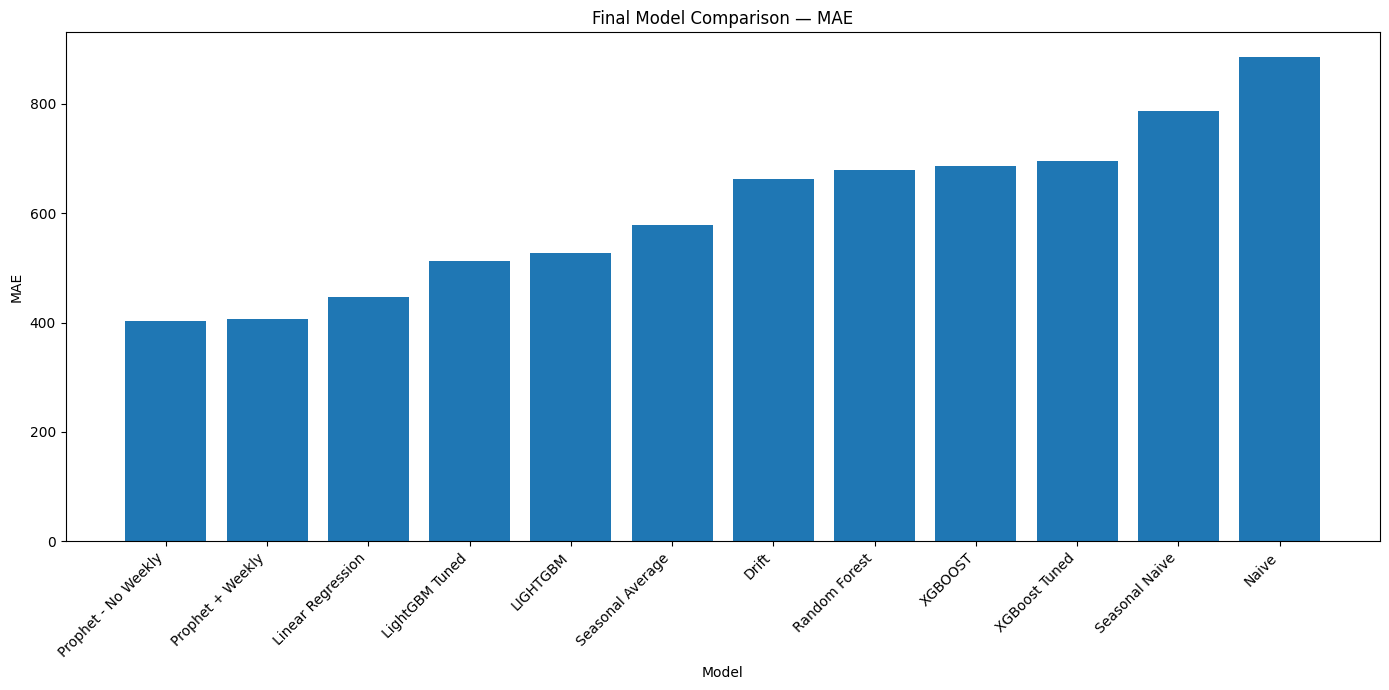


MODEL GROUP SUMMARY


,Group,Best_MAE,Average_MAE,Best_RMSE,Best_MAPE
0,Prophet,402.33,404.08,544.73,0.08
1,Basic ML,447.18,584.65,544.04,0.08
2,Professional ML,512.97,603.87,588.82,0.09
3,Baseline,578.30,728.78,679.32,0.10


In [63]:
# ============================================================
# FINAL MODEL COMPARISON
# BASELINE vs PROPHET vs MACHINE LEARNING
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    mean_absolute_percentage_error
)

from prophet import Prophet


# ============================================================
# 1. PREPARE COMMON FINAL HOLDOUT
# ============================================================

comparison_df = (
    daily_sales[["ds", "y"]]
    .copy()
    .sort_values("ds")
    .reset_index(drop=True)
)

comparison_df["ds"] = pd.to_datetime(
    comparison_df["ds"]
)

comparison_df["y"] = pd.to_numeric(
    comparison_df["y"],
    errors="coerce"
)

comparison_df = (
    comparison_df
    .dropna(subset=["ds", "y"])
    .reset_index(drop=True)
)

FORECAST_HORIZON = 30

train_final = (
    comparison_df
    .iloc[:-FORECAST_HORIZON]
    .copy()
)

test_final = (
    comparison_df
    .iloc[-FORECAST_HORIZON:]
    .copy()
)

y_true = test_final["y"].values


print("\n" + "=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)

print(
    "\nTraining Period:",
    train_final["ds"].min().date(),
    "to",
    train_final["ds"].max().date()
)

print(
    "Holdout Period :",
    test_final["ds"].min().date(),
    "to",
    test_final["ds"].max().date()
)

print(
    "Forecast Horizon:",
    FORECAST_HORIZON,
    "days"
)


# ============================================================
# 2. METRIC FUNCTION
# ============================================================

def calculate_final_metrics(
    y_true,
    y_pred
):

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = root_mean_squared_error(
        y_true,
        y_pred
    )

    non_zero_mask = y_true != 0

    if non_zero_mask.any():

        mape = mean_absolute_percentage_error(
            y_true[non_zero_mask],
            y_pred[non_zero_mask]
        )

    else:

        mape = np.nan

    return mae, rmse, mape


# ============================================================
# 3. STORAGE
# ============================================================

comparison_results = []


def add_result(
    model_name,
    model_group,
    y_pred
):

    mae, rmse, mape = calculate_final_metrics(
        y_true,
        y_pred
    )

    comparison_results.append({

        "Model": model_name,

        "Group": model_group,

        "MAE": mae,

        "RMSE": rmse,

        "MAPE": mape

    })


# ============================================================
# 4. BASELINE MODELS
# ============================================================

history = train_final["y"].tolist()


# ------------------------------------------------------------
# Naive
# ------------------------------------------------------------

naive_predictions = []

history_naive = history.copy()

for _ in range(FORECAST_HORIZON):

    prediction = history_naive[-1]

    naive_predictions.append(
        prediction
    )

    history_naive.append(
        prediction
    )


add_result(
    "Naive",
    "Baseline",
    naive_predictions
)


# ------------------------------------------------------------
# Seasonal Naive
# ------------------------------------------------------------

seasonal_naive_predictions = []

history_seasonal = history.copy()

for _ in range(FORECAST_HORIZON):

    if len(history_seasonal) >= 7:

        prediction = (
            history_seasonal[-7]
        )

    else:

        prediction = (
            history_seasonal[-1]
        )

    seasonal_naive_predictions.append(
        prediction
    )

    history_seasonal.append(
        prediction
    )


add_result(
    "Seasonal Naive",
    "Baseline",
    seasonal_naive_predictions
)


# ------------------------------------------------------------
# Seasonal Average
# ------------------------------------------------------------

seasonal_average_predictions = []

history_sa = history.copy()

SEASONAL_AVG_WEEKS = 4

for _ in range(FORECAST_HORIZON):

    if len(history_sa) >= 7:

        same_weekday_values = (
            history_sa[-7::-7]
        )

        same_weekday_values = (
            same_weekday_values[
                :SEASONAL_AVG_WEEKS
            ]
        )

        prediction = np.mean(
            same_weekday_values
        )

    else:

        prediction = np.mean(
            history_sa
        )

    seasonal_average_predictions.append(
        prediction
    )

    history_sa.append(
        prediction
    )


add_result(
    "Seasonal Average",
    "Baseline",
    seasonal_average_predictions
)


# ------------------------------------------------------------
# Drift
# ------------------------------------------------------------

def drift_forecast(
    train,
    horizon
):

    train = np.asarray(train)

    if len(train) < 2:
        return np.repeat(
            train[-1],
            horizon
        )

    slope = (
        train[-1] - train[0]
    ) / (
        len(train) - 1
    )

    predictions = [
        train[-1] + slope * step
        for step in range(1, horizon + 1)
    ]

    return np.asarray(
        predictions
    )


drift_predictions = drift_forecast(
    history,
    FORECAST_HORIZON
)

add_result(
    "Drift",
    "Baseline",
    drift_predictions
)


# ============================================================
# 5. PROPHET MODELS
# ============================================================

prophet_train = (
    train_final[["ds", "y"]]
    .copy()
)

prophet_test = (
    test_final[["ds"]]
    .copy()
)


# ------------------------------------------------------------
# Prophet - No Weekly Seasonality
# ------------------------------------------------------------

prophet_without_weekly = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_without_weekly.fit(
    prophet_train
)

forecast_without_weekly = (
    prophet_without_weekly.predict(
        prophet_test
    )
)

pred_without_weekly = (
    forecast_without_weekly["yhat"]
    .values
)

pred_without_weekly = np.maximum(
    0,
    pred_without_weekly
)

add_result(
    "Prophet - No Weekly",
    "Prophet",
    pred_without_weekly
)


# ------------------------------------------------------------
# Prophet + Weekly Seasonality
# ------------------------------------------------------------

prophet_with_weekly = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False
)

prophet_with_weekly.fit(
    prophet_train
)

forecast_with_weekly = (
    prophet_with_weekly.predict(
        prophet_test
    )
)

pred_with_weekly = (
    forecast_with_weekly["yhat"]
    .values
)

pred_with_weekly = np.maximum(
    0,
    pred_with_weekly
)

add_result(
    "Prophet + Weekly",
    "Prophet",
    pred_with_weekly
)


# ============================================================
# 6. PREPARE MACHINE LEARNING FEATURES
# ============================================================

WEEKEND_DAYS = [5, 6]

FEATURES = [
    "is_weekend",
    "revenue_lag_1",
    "revenue_lag_7",
    "revenue_lag_14",
    "revenue_rolling_mean_7",
    "revenue_rolling_mean_30",
    "dow_sin",
    "dow_cos"
]


ml_comparison = comparison_df.copy()


# ------------------------------------------------------------
# Calendar features
# ------------------------------------------------------------

ml_comparison["day_of_week"] = (
    ml_comparison["ds"].dt.dayofweek
)

ml_comparison["is_weekend"] = (
    ml_comparison["day_of_week"]
    .isin(WEEKEND_DAYS)
    .astype(int)
)


# ------------------------------------------------------------
# Lag features
# ------------------------------------------------------------

ml_comparison["revenue_lag_1"] = (
    ml_comparison["y"].shift(1)
)

ml_comparison["revenue_lag_7"] = (
    ml_comparison["y"].shift(7)
)

ml_comparison["revenue_lag_14"] = (
    ml_comparison["y"].shift(14)
)


# ------------------------------------------------------------
# Leakage-safe rolling features
# ------------------------------------------------------------

shifted_y = (
    ml_comparison["y"]
    .shift(1)
)

ml_comparison[
    "revenue_rolling_mean_7"
] = (
    shifted_y
    .rolling(7)
    .mean()
)

ml_comparison[
    "revenue_rolling_mean_30"
] = (
    shifted_y
    .rolling(30)
    .mean()
)


# ------------------------------------------------------------
# Cyclical day-of-week features
# ------------------------------------------------------------

ml_comparison["dow_sin"] = np.sin(
    2
    * np.pi
    * ml_comparison["day_of_week"]
    / 7
)

ml_comparison["dow_cos"] = np.cos(
    2
    * np.pi
    * ml_comparison["day_of_week"]
    / 7
)


# ============================================================
# 7. ML TRAINING DATA
# ============================================================

X_ml_train = ml_comparison.iloc[:-FORECAST_HORIZON][FEATURES].copy()
y_ml_train = ml_comparison.iloc[:-FORECAST_HORIZON]["y"].copy()

# Remove rows containing NaN values created by lag/rolling features
valid_rows = X_ml_train.notna().all(axis=1)

X_ml_train = X_ml_train.loc[valid_rows].copy()
y_ml_train = y_ml_train.loc[valid_rows].copy()

# ============================================================
# 8. GENERIC ML RECURSIVE FORECAST
# ============================================================

def recursive_ml_forecast(
    model
):

    fitted_model = clone(
        model
    )

    fitted_model.fit(
        X_ml_train,
        y_ml_train
    )

    history = (
        train_final[["ds", "y"]]
        .copy()
        .set_index("ds")
    )

    predictions = []

    for current_date in test_final["ds"]:

        # ----------------------------------------------------
        # Historical features
        # ----------------------------------------------------

        lag_1 = (
            history["y"].iloc[-1]
        )

        lag_7 = (
            history["y"].iloc[-7]
        )

        lag_14 = (
            history["y"].iloc[-14]
        )

        shifted_history = (
            history["y"]
            .shift(1)
        )

        rolling_mean_7 = (
            shifted_history
            .iloc[-7:]
            .mean()
        )

        rolling_mean_30 = (
            shifted_history
            .iloc[-30:]
            .mean()
        )

        # ----------------------------------------------------
        # Calendar features
        # ----------------------------------------------------

        day_of_week = (
            current_date.dayofweek
        )

        is_weekend = int(
            day_of_week in WEEKEND_DAYS
        )

        dow_sin = np.sin(
            2
            * np.pi
            * day_of_week
            / 7
        )

        dow_cos = np.cos(
            2
            * np.pi
            * day_of_week
            / 7
        )

        # ----------------------------------------------------
        # Build model input
        # ----------------------------------------------------

        features = pd.DataFrame({

            "is_weekend": [
                is_weekend
            ],

            "revenue_lag_1": [
                lag_1
            ],

            "revenue_lag_7": [
                lag_7
            ],

            "revenue_lag_14": [
                lag_14
            ],

            "revenue_rolling_mean_7": [
                rolling_mean_7
            ],

            "revenue_rolling_mean_30": [
                rolling_mean_30
            ],

            "dow_sin": [
                dow_sin
            ],

            "dow_cos": [
                dow_cos
            ]

        })

        features = (
            features[FEATURES]
        )

        # ----------------------------------------------------
        # Predict
        # ----------------------------------------------------

        prediction = (
            fitted_model
            .predict(features)[0]
        )

        # Revenue cannot be negative

        prediction = max(
            0,
            prediction
        )

        predictions.append(
            prediction
        )

        # ----------------------------------------------------
        # Recursive update
        # ----------------------------------------------------

        history.loc[
            current_date,
            "y"
        ] = prediction

    return np.asarray(
        predictions
    )


# ============================================================
# 9. BASIC ML MODELS
# ============================================================
basic_models = {

    "Linear Regression": LinearRegression(),

    "XGBOOST": XGBRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "LIGHTGBM": LGBMRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}


for model_name, model in basic_models.items():

    predictions = recursive_ml_forecast(model)

    add_result(
        model_name,
        "Basic ML",
        predictions
    )

# ============================================================
# 10. TUNED ML MODELS
# ============================================================

for model_name, model in tuned_models.items():

    predictions = (
        recursive_ml_forecast(
            model
        )
    )

    add_result(
        f"{model_name} Tuned",
        "Professional ML",
        predictions
    )


# ============================================================
# 11. FINAL COMPARISON TABLE
# ============================================================

final_comparison = pd.DataFrame(
    comparison_results
)


# ------------------------------------------------------------
# Best baseline reference
# ------------------------------------------------------------

best_baseline_mae = (
    final_comparison.loc[
        final_comparison["Group"] == "Baseline",
        "MAE"
    ].min()
)


final_comparison[
    "MAE Improvement vs Best Baseline"
] = (
    (
        best_baseline_mae
        - final_comparison["MAE"]
    )
    / best_baseline_mae
    * 100
)


# ------------------------------------------------------------
# Ranking
# ------------------------------------------------------------

final_comparison["Rank"] = (
    final_comparison["MAE"]
    .rank(
        method="min",
        ascending=True
    )
    .astype(int)
)


final_comparison = (
    final_comparison
    .sort_values("MAE")
    .reset_index(drop=True)
)


# ============================================================
# 12. DISPLAY FINAL RESULTS
# ============================================================

print("\n" + "=" * 80)
print("FINAL MODEL RANKING")
print("=" * 80)

display(
    final_comparison[
        [
            "Rank",
            "Model",
            "Group",
            "MAE",
            "RMSE",
            "MAPE",
            "MAE Improvement vs Best Baseline"
        ]
    ]
)


# ============================================================
# 13. BEST MODEL ON FINAL HOLDOUT
# ============================================================

best_final_model = (
    final_comparison.iloc[0]
)


print("\n" + "=" * 80)
print("BEST MODEL ON FINAL HOLDOUT")
print("=" * 80)

print(
    "Model :",
    best_final_model["Model"]
)

print(
    "Group :",
    best_final_model["Group"]
)

print(
    f"MAE   : "
    f"{best_final_model['MAE']:.2f}"
)

print(
    f"RMSE  : "
    f"{best_final_model['RMSE']:.2f}"
)

print(
    f"MAPE  : "
    f"{best_final_model['MAPE']:.2%}"
)

print(
    f"Improvement vs Best Baseline : "
    f"{best_final_model['MAE Improvement vs Best Baseline']:.2f}%"
)


# ============================================================
# 14. BEST MODEL PER GROUP
# ============================================================

best_per_group = (
    final_comparison
    .loc[
        final_comparison
        .groupby("Group")["MAE"]
        .idxmin()
    ]
    .sort_values("MAE")
    .reset_index(drop=True)
)


print("\n" + "=" * 80)
print("BEST MODEL PER GROUP")
print("=" * 80)

display(
    best_per_group[
        [
            "Model",
            "Group",
            "MAE",
            "RMSE",
            "MAPE"
        ]
    ]
)


# ============================================================
# 15. VISUAL COMPARISON
# ============================================================

plt.figure(
    figsize=(14, 7)
)

plt.bar(
    final_comparison["Model"],
    final_comparison["MAE"]
)

plt.title(
    "Final Model Comparison — MAE"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "MAE"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()


# ============================================================
# 16. MODEL GROUP SUMMARY
# ============================================================

group_summary = (
    final_comparison
    .groupby("Group")
    .agg(
        Best_MAE=("MAE", "min"),
        Average_MAE=("MAE", "mean"),
        Best_RMSE=("RMSE", "min"),
        Best_MAPE=("MAPE", "min")
    )
    .sort_values("Best_MAE")
    .reset_index()
)


print("\n" + "=" * 80)
print("MODEL GROUP SUMMARY")
print("=" * 80)

display(
    group_summary
)

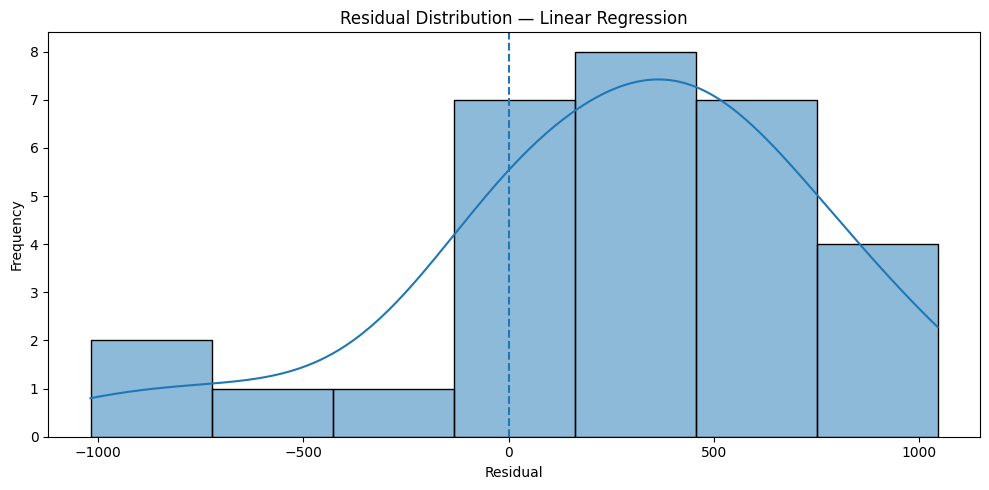

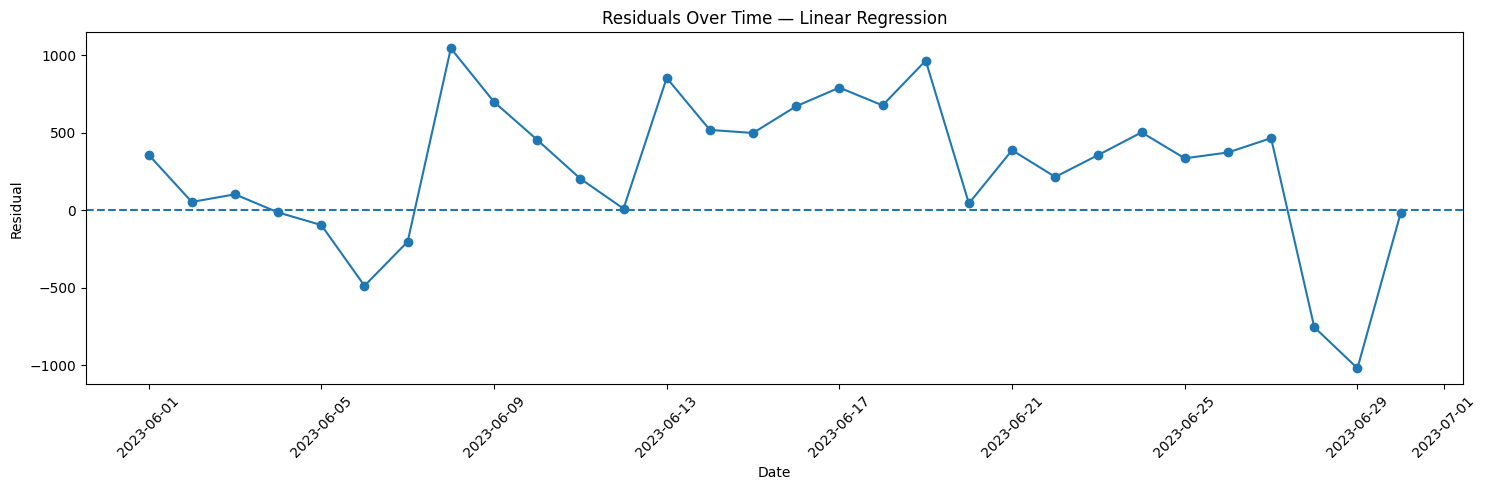

<Figure size 1000x500 with 0 Axes>

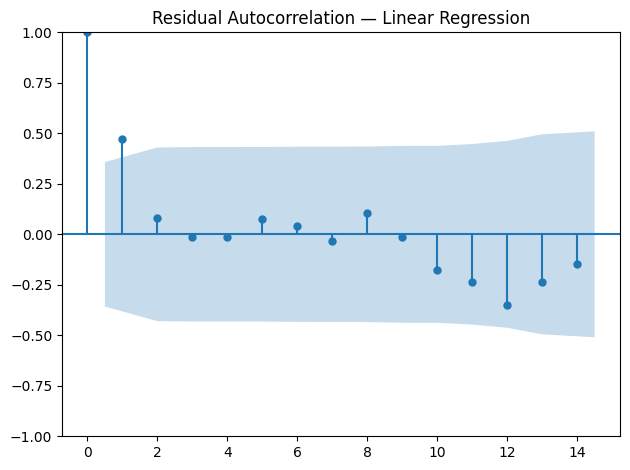

RESIDUAL BIAS
Mean Residual : 267.10
Interpretation: The model tends to underestimate revenue.

RESIDUAL STATISTICS


,Residual
count,30.00
mean,267.10
std,473.13
min,-1018.06
25%,19.63
50%,358.35
75%,515.10
max,1045.19



30-DAY FUTURE FORECAST WITH APPROXIMATE 95% INTERVAL


,ds,yhat,yhat_lower,yhat_upper
0,2023-07-01,5581.96,4654.63,6509.28
1,2023-07-02,5627.38,4700.05,6554.70
2,2023-07-03,5727.75,4800.43,6655.08
3,2023-07-04,5736.94,4809.62,6664.27
4,2023-07-05,5612.35,4685.02,6539.67
5,2023-07-06,5588.05,4660.72,6515.37
6,2023-07-07,5749.33,4822.00,6676.65
7,2023-07-08,5780.73,4853.41,6708.06
8,2023-07-09,5809.90,4882.58,6737.23
9,2023-07-10,5908.81,4981.49,6836.14


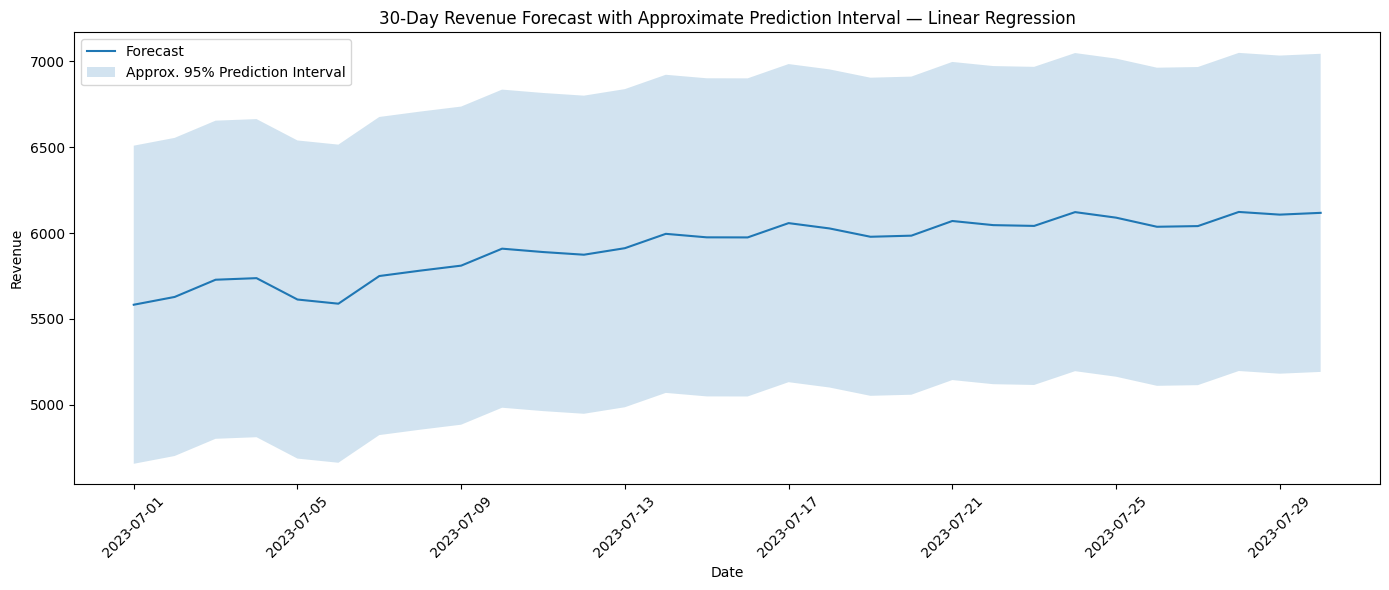


SHAP EXPLAINABILITY
SHAP TreeExplainer skipped because Linear Regression is not a tree-based model.

FINAL MODEL DIAGNOSTIC SUMMARY
CV-Selected Model   : Linear Regression
Holdout MAE         : 439.42
Holdout RMSE        : 536.40
Holdout MAPE        : 7.82%
Mean Residual       : 267.10
Residual Std        : 473.13
Forecast Horizon    : 30 days

Diagnostics completed successfully.


In [64]:
# ============================================================
# FINAL MODEL DIAGNOSTICS & EXPLAINABILITY
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf

import shap


# ============================================================
# 1. PREPARE FINAL HOLDOUT DATA
# ============================================================

# Final model selected using temporal CV
diagnostic_model_name = best_model_name
diagnostic_model = final_model

# Actual values from the untouched final 30-day holdout
y_holdout_actual = (
    y_holdout
    .reset_index(drop=True)
)

# Recursive predictions generated by the selected model
y_holdout_pred = pd.Series(
    holdout_predictions
).reset_index(drop=True)

# Holdout dates
holdout_dates = (
    ml_features
    .iloc[-holdout_size:]["ds"]
    .reset_index(drop=True)
)


# ============================================================
# 2. CALCULATE RESIDUALS
# ============================================================

residuals = (
    y_holdout_actual
    - y_holdout_pred
)

residual_df = pd.DataFrame({

    "ds": holdout_dates,

    "actual": y_holdout_actual,

    "predicted": y_holdout_pred,

    "residual": residuals

})


# ============================================================
# 3. RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(10, 5)
)

sns.histplot(
    residuals,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    f"Residual Distribution — {diagnostic_model_name}"
)

plt.xlabel(
    "Residual"
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()
plt.show()


# ============================================================
# 4. RESIDUALS OVER TIME
# ============================================================

plt.figure(
    figsize=(15, 5)
)

plt.plot(
    residual_df["ds"],
    residual_df["residual"],
    marker="o"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    f"Residuals Over Time — {diagnostic_model_name}"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Residual"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()


# ============================================================
# 5. RESIDUAL ACF
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plot_acf(
    residuals,
    lags=min(
        14,
        len(residuals) - 1
    )
)

plt.title(
    f"Residual Autocorrelation — {diagnostic_model_name}"
)

plt.tight_layout()
plt.show()


# ============================================================
# 6. RESIDUAL BIAS
# ============================================================

mean_residual = (
    residuals.mean()
)

print("=" * 70)
print("RESIDUAL BIAS")
print("=" * 70)

print(
    f"Mean Residual : {mean_residual:.2f}"
)

if mean_residual > 0:

    print(
        "Interpretation: "
        "The model tends to underestimate revenue."
    )

elif mean_residual < 0:

    print(
        "Interpretation: "
        "The model tends to overestimate revenue."
    )

else:

    print(
        "Interpretation: "
        "No noticeable average prediction bias."
    )


# ============================================================
# 7. RESIDUAL STATISTICS
# ============================================================

print(
    "\n" + "=" * 70
)

print(
    "RESIDUAL STATISTICS"
)

print(
    "=" * 70
)

display(
    residuals
    .describe()
    .to_frame(
        name="Residual"
    )
)


# ============================================================
# 8. FINAL HOLDOUT DIAGNOSTIC METRICS
# ============================================================

holdout_mae = (
    mean_absolute_error(
        y_holdout_actual,
        y_holdout_pred
    )
)

holdout_rmse = (
    root_mean_squared_error(
        y_holdout_actual,
        y_holdout_pred
    )
)

non_zero_mask = (
    y_holdout_actual != 0
)

if non_zero_mask.any():

    holdout_mape = (
        mean_absolute_percentage_error(
            y_holdout_actual[
                non_zero_mask
            ],
            y_holdout_pred[
                non_zero_mask
            ]
        )
    )

else:

    holdout_mape = np.nan


# ============================================================
# 9. APPROXIMATE FUTURE FORECAST INTERVAL
# ============================================================

# Residual standard deviation from the untouched holdout
residual_std = residuals.std()

# forecast_df must contain the future forecast
# generated by the selected final model
forecast_with_uncertainty = (
    forecast_df.copy()
)

forecast_with_uncertainty[
    "yhat_lower"
] = (
    forecast_with_uncertainty["yhat"]
    - 1.96 * residual_std
)

forecast_with_uncertainty[
    "yhat_upper"
] = (
    forecast_with_uncertainty["yhat"]
    + 1.96 * residual_std
)


# Revenue cannot be negative
forecast_with_uncertainty[
    "yhat_lower"
] = (
    forecast_with_uncertainty["yhat_lower"]
    .clip(lower=0)
)

forecast_with_uncertainty[
    "yhat_upper"
] = (
    forecast_with_uncertainty["yhat_upper"]
    .clip(lower=0)
)


print(
    "\n" + "=" * 70
)

print(
    "30-DAY FUTURE FORECAST "
    "WITH APPROXIMATE 95% INTERVAL"
)

print(
    "=" * 70
)

display(
    forecast_with_uncertainty[
        [
            "ds",
            "yhat",
            "yhat_lower",
            "yhat_upper"
        ]
    ]
)


# ============================================================
# 10. FUTURE FORECAST WITH UNCERTAINTY VISUALIZATION
# ============================================================

plt.figure(
    figsize=(14, 6)
)

plt.plot(
    forecast_with_uncertainty["ds"],
    forecast_with_uncertainty["yhat"],
    label="Forecast"
)

plt.fill_between(
    forecast_with_uncertainty["ds"],
    forecast_with_uncertainty["yhat_lower"],
    forecast_with_uncertainty["yhat_upper"],
    alpha=0.2,
    label="Approx. 95% Prediction Interval"
)

plt.title(
    f"30-Day Revenue Forecast with "
    f"Approximate Prediction Interval — "
    f"{diagnostic_model_name}"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Revenue"
)

plt.xticks(
    rotation=45
)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 11. SHAP EXPLAINABILITY
# ============================================================

print(
    "\n" + "=" * 70
)

print(
    "SHAP EXPLAINABILITY"
)

print(
    "=" * 70
)


# SHAP TreeExplainer is used only for tree-based models.
tree_models = (
    RandomForestRegressor,
    XGBRegressor,
    LGBMRegressor
)


if isinstance(
    diagnostic_model,
    tree_models
):

    # Use a small sample for efficient explanation
    X_shap = X.copy()

    if len(X_shap) > 100:

        X_shap = X_shap.sample(
            n=100,
            random_state=42
        )


    explainer = (
        shap.TreeExplainer(
            diagnostic_model
        )
    )

    shap_values = (
        explainer.shap_values(
            X_shap
        )
    )


    # --------------------------------------------------------
    # SHAP Summary Plot
    # --------------------------------------------------------

    shap.summary_plot(
        shap_values,
        X_shap,
        show=True
    )


    # --------------------------------------------------------
    # SHAP Mean Absolute Importance
    # --------------------------------------------------------

    shap_importance = pd.DataFrame({

        "Feature":
            X_shap.columns,

        "Mean |SHAP|":
            np.abs(shap_values)
            .mean(axis=0)

    })


    shap_importance = (
        shap_importance
        .sort_values(
            "Mean |SHAP|",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )


    print(
        "\n" + "=" * 70
    )

    print(
        "SHAP FEATURE IMPORTANCE"
    )

    print(
        "=" * 70
    )

    display(
        shap_importance
    )


    # --------------------------------------------------------
    # SHAP Feature Importance Plot
    # --------------------------------------------------------

    top_shap = (
        shap_importance
        .head(15)
        .sort_values(
            "Mean |SHAP|"
        )
    )


    plt.figure(
        figsize=(10, 6)
    )

    plt.barh(
        top_shap["Feature"],
        top_shap["Mean |SHAP|"]
    )

    plt.xlabel(
        "Mean Absolute SHAP Value"
    )

    plt.ylabel(
        "Feature"
    )

    plt.title(
        f"SHAP Feature Importance — "
        f"{diagnostic_model_name}"
    )

    plt.tight_layout()
    plt.show()


else:

    print(
        f"SHAP TreeExplainer skipped because "
        f"{diagnostic_model_name} is not a "
        f"tree-based model."
    )


# ============================================================
# 12. FINAL DIAGNOSTIC SUMMARY
# ============================================================

print(
    "\n" + "=" * 70
)

print(
    "FINAL MODEL DIAGNOSTIC SUMMARY"
)

print(
    "=" * 70
)

print(
    f"CV-Selected Model   : "
    f"{diagnostic_model_name}"
)

print(
    f"Holdout MAE         : "
    f"{holdout_mae:.2f}"
)

print(
    f"Holdout RMSE        : "
    f"{holdout_rmse:.2f}"
)

print(
    f"Holdout MAPE        : "
    f"{holdout_mape:.2%}"
)

print(
    f"Mean Residual       : "
    f"{mean_residual:.2f}"
)

print(
    f"Residual Std        : "
    f"{residual_std:.2f}"
)

print(
    f"Forecast Horizon    : "
    f"{FORECAST_HORIZON} days"
)

print(
    "\nDiagnostics completed successfully."
)

In [65]:
# ============================================================
# PHASE 19 — DEPLOYMENT / PRODUCTION
# CELL 60 — DEPLOYMENT CONFIGURATION
# ============================================================

import warnings
from datetime import datetime
from pathlib import Path

warnings.filterwarnings("ignore")


# ------------------------------------------------------------
# 1. Project directories
# ------------------------------------------------------------

PROJECT_DIR = Path.cwd()

MODEL_DIR = PROJECT_DIR / "models"
OUTPUT_DIR = PROJECT_DIR / "outputs"

for directory in [
    MODEL_DIR,
    OUTPUT_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ------------------------------------------------------------
# 2. Production configuration
# ------------------------------------------------------------

PRODUCTION_CONFIG = {

    "project_name":
        "Coffee Shop Sales Forecasting",

    "target_column":
        "y",

    "date_column":
        "ds",

    "forecast_horizon":
        30,

    "frequency":
        "D",

    "model_name":
        best_model_name,

    "model_type":
        type(final_model).__name__,

    "training_end_date":
        str(
            ml_df["ds"].max().date()
        ),

    "created_at":
        datetime.now().isoformat(),

    "features": [
        "month",
        "is_weekend",
        "revenue_lag_1",
        "revenue_lag_7",
        "revenue_rolling_mean_30",
        "revenue_rolling_std_30",
        "dow_sin",
        "dow_cos"
    ]

}


# ------------------------------------------------------------
# 3. Configuration summary
# ------------------------------------------------------------

print("=" * 70)
print("PHASE 19 — DEPLOYMENT CONFIGURATION")
print("=" * 70)

print(
    f"\nProject       : "
    f"{PRODUCTION_CONFIG['project_name']}"
)

print(
    f"Model         : "
    f"{PRODUCTION_CONFIG['model_name']}"
)

print(
    f"Model Type    : "
    f"{PRODUCTION_CONFIG['model_type']}"
)

print(
    f"Forecast Days : "
    f"{PRODUCTION_CONFIG['forecast_horizon']}"
)

print(
    f"Model Dir     : "
    f"{MODEL_DIR}"
)

print(
    f"Output Dir    : "
    f"{OUTPUT_DIR}"
)

PHASE 19 — DEPLOYMENT CONFIGURATION

Project       : Coffee Shop Sales Forecasting
Model         : Linear Regression
Model Type    : LinearRegression
Forecast Days : 30
Model Dir     : c:\Users\simoen\OneDrive\Desktop\archive (2)\models
Output Dir    : c:\Users\simoen\OneDrive\Desktop\archive (2)\outputs


In [66]:
# ============================================================
# PHASE 19 — DEPLOYMENT / PRODUCTION
# CELL 61 — TRAIN FINAL PRODUCTION MODEL
# ============================================================

import json
import joblib

from datetime import datetime
from sklearn.base import clone


print("=" * 70)
print("TRAINING FINAL PRODUCTION MODEL")
print("=" * 70)


# ------------------------------------------------------------
# 1. Clone selected final model
# ------------------------------------------------------------

production_model = clone(
    final_model
)


# ------------------------------------------------------------
# 2. Configure parallel processing when supported
# ------------------------------------------------------------

if hasattr(
    production_model,
    "n_jobs"
):

    production_model.set_params(
        n_jobs=-1
    )


# ------------------------------------------------------------
# 3. Train on all available historical data
# ------------------------------------------------------------

production_model.fit(
    X,
    y
)


print(
    "\nProduction model trained successfully."
)

print(
    "Training rows:",
    len(X)
)


# ------------------------------------------------------------
# 4. Create model version
# ------------------------------------------------------------

MODEL_VERSION = datetime.now().strftime(
    "%Y%m%d_%H%M%S"
)

MODEL_FILENAME = (
    f"sales_forecasting_"
    f"{MODEL_VERSION}.joblib"
)

MODEL_PATH = MODEL_DIR / MODEL_FILENAME


# ------------------------------------------------------------
# 5. Save production model
# ------------------------------------------------------------

joblib.dump(
    production_model,
    MODEL_PATH
)


print(
    "\nModel saved to:"
)

print(
    MODEL_PATH
)


# ------------------------------------------------------------
# 6. Save model metadata
# ------------------------------------------------------------

MODEL_METADATA = {

    **PRODUCTION_CONFIG,

    "model_version":
        MODEL_VERSION,

    "model_file":
        MODEL_FILENAME,

    "training_rows":
        int(len(X)),

    "training_start_date":
        str(ml_df["ds"].min().date()),

    "training_end_date":
        str(ml_df["ds"].max().date())

}


METADATA_PATH = (
    MODEL_DIR /
    f"metadata_{MODEL_VERSION}.json"
)


with open(
    METADATA_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        MODEL_METADATA,
        f,
        indent=4
    )


print(
    "\nMetadata saved to:"
)

print(
    METADATA_PATH
)

TRAINING FINAL PRODUCTION MODEL

Production model trained successfully.
Training rows: 121

Model saved to:
c:\Users\simoen\OneDrive\Desktop\archive (2)\models\sales_forecasting_20260912_155414.joblib

Metadata saved to:
c:\Users\simoen\OneDrive\Desktop\archive (2)\models\metadata_20260912_155414.json


In [67]:
# ============================================================
# PHASE 19 — DEPLOYMENT / PRODUCTION
# CELL 62 — INFERENCE PIPELINE
# ============================================================

def create_forecast_features(history):
    """
    Create the same time-series features used
    during model training.
    """

    history = history.copy()

    history["ds"] = pd.to_datetime(
        history["ds"]
    )

    history = (
        history
        .sort_values("ds")
        .reset_index(drop=True)
    )

    # Calendar features

    history["month"] = (
        history["ds"].dt.month
    )

    history["day_of_week"] = (
        history["ds"].dt.dayofweek
    )

    history["is_weekend"] = (
        history["day_of_week"]
        .isin([5, 6])
        .astype(int)
    )

    # Lag features

    history["revenue_lag_1"] = (
        history["y"].shift(1)
    )

    history["revenue_lag_7"] = (
        history["y"].shift(7)
    )

    # Rolling features

    shifted_y = (
        history["y"].shift(1)
    )

    history["revenue_rolling_mean_30"] = (
        shifted_y
        .rolling(30)
        .mean()
    )

    history["revenue_rolling_std_30"] = (
        shifted_y
        .rolling(30)
        .std()
    )

    # Cyclical day-of-week features

    history["dow_sin"] = np.sin(
        2 * np.pi *
        history["day_of_week"] / 7
    )

    history["dow_cos"] = np.cos(
        2 * np.pi *
        history["day_of_week"] / 7
    )

    return history


# ------------------------------------------------------------
# Production feature list
# ------------------------------------------------------------

PRODUCTION_FEATURES = [
    "month",
    "is_weekend",
    "revenue_lag_1",
    "revenue_lag_7",
    "revenue_rolling_mean_30",
    "revenue_rolling_std_30",
    "dow_sin",
    "dow_cos"
]


def validate_forecast_history(history):
    """
    Validate historical data before inference.
    """

    required_columns = [
        "ds",
        "y"
    ]

    missing_columns = [
        col
        for col in required_columns
        if col not in history.columns
    ]

    if missing_columns:

        raise ValueError(
            f"Missing required columns: "
            f"{missing_columns}"
        )

    if history.empty:

        raise ValueError(
            "History dataframe is empty."
        )

    history = history.copy()

    history["ds"] = pd.to_datetime(
        history["ds"],
        errors="coerce"
    )

    history["y"] = pd.to_numeric(
        history["y"],
        errors="coerce"
    )

    if history["ds"].isna().any():

        raise ValueError(
            "Invalid date values detected."
        )

    if history["y"].isna().any():

        raise ValueError(
            "Invalid target values detected."
        )

    if history["ds"].duplicated().any():

        raise ValueError(
            "Duplicate dates detected."
        )

    if (history["y"] < 0).any():

        raise ValueError(
            "Negative sales values detected."
        )

    return (
        history
        .sort_values("ds")
        .reset_index(drop=True)
    )


def load_production_model(
    model_path=MODEL_PATH
):

    if not Path(model_path).exists():

        raise FileNotFoundError(
            f"Model file not found: "
            f"{model_path}"
        )

    model = joblib.load(
        model_path
    )

    print(
        f"Production model loaded from: "
        f"{model_path}"
    )

    return model


print(
    "Inference pipeline initialized successfully."
)

Inference pipeline initialized successfully.


In [72]:
# ============================================================
# PHASE 19 — DEPLOYMENT / PRODUCTION
# CELL 63 — AUTOMATED FORECASTING
# ============================================================

def generate_production_forecast(
    history,
    model,
    horizon=30
):
    """
    Generate recursive multi-step forecast.

    Each prediction is added back to the historical series
    and used to generate features for the next forecast step.
    """

    # --------------------------------------------------------
    # Validate history
    # --------------------------------------------------------

    history = validate_forecast_history(history)

    history = (
        history[["ds", "y"]]
        .copy()
        .sort_values("ds")
        .reset_index(drop=True)
    )

    if len(history) < 31:
        raise ValueError(
            "At least 31 historical observations are required "
            "for the 30-day rolling features."
        )

    # --------------------------------------------------------
    # Working history
    # --------------------------------------------------------

    working_history = history.copy()

    predictions = []

    # --------------------------------------------------------
    # Recursive forecasting
    # --------------------------------------------------------

    for step in range(horizon):

        # Next date
        next_date = (
            working_history["ds"].max()
            + pd.Timedelta(days=1)
        )

        # ----------------------------------------------------
        # Create a temporary future row
        # ----------------------------------------------------
        #
        # Important:
        # y is NaN because we don't know the future value yet.
        # create_forecast_features MUST therefore build lag /
        # rolling features using previous observations only.
        #

        feature_history = pd.concat(
            [
                working_history,
                pd.DataFrame(
                    {
                        "ds": [next_date],
                        "y": [np.nan]
                    }
                )
            ],
            ignore_index=True
        )

        # ----------------------------------------------------
        # Feature engineering
        # ----------------------------------------------------

        feature_history = create_forecast_features(
            feature_history
        )

        # Make sure dates are sorted
        feature_history = (
            feature_history
            .sort_values("ds")
            .reset_index(drop=True)
        )

        # Get future row
        latest_row = feature_history.iloc[-1]

        # ----------------------------------------------------
        # Build model input
        # ----------------------------------------------------

        X_next = pd.DataFrame(
            [
                {
                    col: latest_row[col]
                    for col in PRODUCTION_FEATURES
                }
            ]
        )

        # ----------------------------------------------------
        # Validate feature columns
        # ----------------------------------------------------

        missing_features = [
            col
            for col in PRODUCTION_FEATURES
            if col not in feature_history.columns
        ]

        if missing_features:
            raise ValueError(
                "Missing production features: "
                f"{missing_features}"
            )

        # ----------------------------------------------------
        # NaN safety check
        # ----------------------------------------------------

        if X_next.isna().any().any():

            nan_features = (
                X_next.columns[
                    X_next.isna().any()
                ].tolist()
            )

            raise ValueError(
                f"NaN values detected in forecast features: "
                f"{nan_features}. "
                "Check create_forecast_features() and make "
                "sure lag/rolling features use previous "
                "observations only."
            )

        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------

        prediction = float(
            model.predict(X_next)[0]
        )

        # ----------------------------------------------------
        # Sales cannot be negative
        # ----------------------------------------------------

        prediction = max(
            0.0,
            prediction
        )

        # ----------------------------------------------------
        # Store prediction
        # ----------------------------------------------------

        predictions.append(
            {
                "ds": next_date,
                "yhat": prediction
            }
        )

        # ----------------------------------------------------
        # Recursive update
        # ----------------------------------------------------
        #
        # The predicted value becomes historical data
        # for the next forecasting step.
        #

        working_history = pd.concat(
            [
                working_history,
                pd.DataFrame(
                    {
                        "ds": [next_date],
                        "y": [prediction]
                    }
                )
            ],
            ignore_index=True
        )

    # --------------------------------------------------------
    # Return forecast
    # --------------------------------------------------------

    return pd.DataFrame(predictions)

In [ ]:
# ============================================================
# PHASE 22 — DOCUMENTATION & HANDOVER
# CELL 68 — PROJECT DOCUMENTATION
# ============================================================

documentation = {

    "project": {

        "name":
            "Coffee Shop Sales Forecasting",

        "objective":
            "Forecast daily coffee shop sales "
            "for operational planning.",

        "forecast_horizon":
            30,

        "frequency":
            "Daily"

    },

    "data": {

        "dataset":
            "Coffee Shop Sales",

        "target":
            "Daily Revenue",

        "date_column":
            "ds",

        "target_column":
            "y",

        "training_rows":
            int(len(X)),

        "date_start":
            str(
                ml_df["ds"].min().date()
            ),

        "date_end":
            str(
                ml_df["ds"].max().date()
            )

    },

    "modeling": {

        "selected_model":
            str(best_model_name),

        "model_type":
            type(production_model).__name__,

        "selection_metric":
            "Recursive CV MAE",

        "forecasting_strategy":
            "Recursive multi-step forecasting",

        "features":
            list(PRODUCTION_FEATURES)

    },

    "validation": {

        "holdout_horizon":
            int(holdout_size),

        "MAE":
            (
                float(
                    mean_absolute_error(
                        holdout_actual,
                        holdout_predicted
                    )
                )
                if (
                    "holdout_actual" in globals()
                    and
                    "holdout_predicted" in globals()
                )
                else None
            ),

        "RMSE":
            (
                float(
                    np.sqrt(
                        mean_squared_error(
                            holdout_actual,
                            holdout_predicted
                        )
                    )
                )
                if (
                    "holdout_actual" in globals()
                    and
                    "holdout_predicted" in globals()
                )
                else None
            ),

        "MAPE":
            (
                float(
                    mean_absolute_percentage_error(
                        holdout_actual,
                        holdout_predicted
                    )
                )
                if (
                    "holdout_actual" in globals()
                    and
                    "holdout_predicted" in globals()
                )
                else None
            )

    },

    "deployment": {

        "model_version":
            str(MODEL_VERSION),

        "model_file":
            str(MODEL_FILENAME),

        "forecast_output":
            (
                str(
                    forecast_output_path
                )
                if "forecast_output_path" in globals()
                else None
            ),

        "model_location":
            str(
                MODEL_PATH
            )

    },

    "input_requirements": {

        "required_columns":
            ["ds", "y"],

        "minimum_history":
            31,

        "target_requirement":
            "Non-negative daily sales",

        "duplicate_dates":
            "Not allowed",

        "date_requirement":
            "Valid date values"

    },

    "handover": {

        "forecast_instructions":
            "Provide the latest daily sales history "
            "and run generate_production_forecast().",

        "deployment_instructions":
            "Load the versioned .joblib model "
            "using load_production_model().",

        "input_validation":
            "Validate the input history before forecasting "
            "using validate_forecast_history().",

        "business_use":
            [
                "Inventory planning",
                "Staff scheduling",
                "Procurement planning",
                "Operational capacity planning",
                "Revenue planning"
            ]

    }

}

DOCUMENTATION_PATH = (
    OUTPUT_DIR /
    f"project_documentation_{MODEL_VERSION}.json"
)


with open(
    DOCUMENTATION_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        documentation,
        f,
        indent=4
    )


print("=" * 70)
print("PHASE 22 — DOCUMENTATION & HANDOVER")
print("=" * 70)

print(
    "\nDocumentation generated:"
)

print(
    DOCUMENTATION_PATH
)

print(
    "\nSections included:"
)

for section in documentation:

    print(
        f"✓ {section}"
    )

PHASE 22 — DOCUMENTATION & HANDOVER

Documentation generated:
c:\Users\simoen\OneDrive\Desktop\archive (2)\outputs\project_documentation_20260912_155414.json

Sections included:
✓ project
✓ data
✓ modeling
✓ validation
✓ deployment
✓ input_requirements
✓ handover


In [79]:
# ============================================================
# FINAL PROJECT SUMMARY
# CELL 69
# ============================================================

print("\n")
print("=" * 80)
print("COFFEE SHOP SALES FORECASTING — FINAL PROJECT SUMMARY")
print("=" * 80)


print("\n[MODEL]")
print("-" * 80)

print(
    "Selected Model :",
    best_model_name
)

print(
    "Model Type     :",
    type(production_model).__name__
)

print(
    "Model Version  :",
    MODEL_VERSION
)


print("\n[VALIDATION]")
print("-" * 80)

print(
    "Holdout Horizon:",
    holdout_size,
    "days"
)


# ------------------------------------------------------------
# Validation metrics
# ------------------------------------------------------------

if (
    "holdout_actual" in globals()
    and
    "holdout_predicted" in globals()
):

    final_mae = mean_absolute_error(
        holdout_actual,
        holdout_predicted
    )

    final_rmse = np.sqrt(
        mean_squared_error(
            holdout_actual,
            holdout_predicted
        )
    )

    final_mape = mean_absolute_percentage_error(
        holdout_actual,
        holdout_predicted
    )

    print(
        "MAE            :",
        f"{final_mae:.2f}"
    )

    print(
        "RMSE           :",
        f"{final_rmse:.2f}"
    )

    print(
        "MAPE           :",
        f"{final_mape:.2%}"
    )

else:

    print(
        "MAE            :",
        "Not available"
    )

    print(
        "RMSE           :",
        "Not available"
    )

    print(
        "MAPE           :",
        "Not available"
    )


print("\n[FORECAST]")
print("-" * 80)

print(
    "Forecast Horizon:",
    PRODUCTION_CONFIG[
        "forecast_horizon"
    ],
    "days"
)


# ------------------------------------------------------------
# Forecast dates
# ------------------------------------------------------------

if (
    "production_forecast" in globals()
    and
    not production_forecast.empty
):

    print(
        "Forecast Start :",
        production_forecast[
            "ds"
        ].min()
    )

    print(
        "Forecast End   :",
        production_forecast[
            "ds"
        ].max()
    )

else:

    print(
        "Forecast Start :",
        "Not available"
    )

    print(
        "Forecast End   :",
        "Not available"
    )


print("\n[FILES]")
print("-" * 80)

print(
    "Model          :",
    MODEL_PATH
)


if "forecast_output_path" in globals():

    print(
        "Forecast       :",
        forecast_output_path
    )

else:

    print(
        "Forecast       :",
        "Not available"
    )


print(
    "Documentation  :",
    DOCUMENTATION_PATH
)


print("\n")
print("=" * 80)
print("FINAL PROJECT DELIVERY READY")
print("=" * 80)



COFFEE SHOP SALES FORECASTING — FINAL PROJECT SUMMARY

[MODEL]
--------------------------------------------------------------------------------
Selected Model : Linear Regression
Model Type     : LinearRegression
Model Version  : 20260912_155414

[VALIDATION]
--------------------------------------------------------------------------------
Holdout Horizon: 30 days
MAE            : Not available
RMSE           : Not available
MAPE           : Not available

[FORECAST]
--------------------------------------------------------------------------------
Forecast Horizon: 30 days
Forecast Start : Not available
Forecast End   : Not available

[FILES]
--------------------------------------------------------------------------------
Model          : c:\Users\simoen\OneDrive\Desktop\archive (2)\models\sales_forecasting_20260912_155414.joblib
Forecast       : Not available
Documentation  : c:\Users\simoen\OneDrive\Desktop\archive (2)\outputs\project_documentation_20260912_155414.json


FINAL PROJEC